# Final report calculations — 2026-08-10

Working notebook for the Pi$^2$ final report (`Pi2Su26/final_report/`): numbers
for the tables and final figure polish. First up: the **measured Bessel-window
range** for each optics configuration candidate of the report's `tab:configs`,
in the report format `L (z ∈ [lo, hi])` (meters, z from axicon 3).

| Candidate | Dataset | Envelope source (existing reduction caches) |
|---|---|---|
| #1 baseline | jul22-23 (+ jul13 manual) | `onaxis_reduction_2026_07_23.json` (0.15 mm-aperture on-axis rate) + `axial_reduction_2026_07_23.json` manual `peak_rate` |
| #2 input beam 2× | jul29-30 | `ax3_reduction_2026_07_29.json` per-slice peak-pixel rate |
| #3 smaller hollow beam | aug5-6 direct | `ax3_core_frames_2026_08_06.csv` best unsaturated core-frame rate |
| #4 = #3 + 2× telescope in zone | aug5-6 telescope | `telescope_core_frames_2026_08_06.csv` — **image-side** $z'$ after f_200mm; image↔object offset NOT recorded, so no object-side mapping yet |

Method: per y, envelope = max unsaturated rate across runs/frames; window =
FWHM about the global peak (linear-interpolated half crossings, walking out
from the peak). Edges beyond the scanned span are reported as unbounded.

Caveats (candidates #1-#2 especially): same-y runs differ up to ~2× in
absolute rate (independent exposure cal + laser drift), and #1's gantry
estimator (aperture mean) differs from the others (peak pixel) — the FWHM
uses only relative shape within one dataset, but the max-over-runs envelope
can inherit steps at run boundaries. Real sub-half dips inside the window
(jul29: ~1.70/1.85 m) are printed as warnings, not excluded.

In [1]:
import csv
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
RED = Path("reductions")

# simulator import (not needed for the measured ranges, kept for later cells);
# webapp repo has both historical spellings
for _name in ("bessel_beam_webapp",):  # NB trailing comma: bare ("x") iterates characters
    if (REPO.parent / _name).exists():
        sys.path.insert(0, str(REPO.parent / _name))
        break

NOTEBOOK_STEM = "final_report_calcs_2026_08_10"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.savefig(path, dpi=800, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
# --- measured Bessel-window ranges, all four candidates ----------------------
# 1. build per-candidate axial envelopes from the existing reduction caches
#    (per y: max unsaturated rate across runs/frames; no raw frames touched)
# 2. FWHM about the global peak: walk out from the peak to the first sample
#    below half, linear-interpolate the crossing; data ending first => edge
#    unbounded (None)
# 3. print each result in the report format  L ($z \in [lo, hi]$)


def envelope(pairs):
    d = {}
    for y, r in pairs:
        d[y] = max(d.get(y, 0.0), r)
    ys = np.array(sorted(d))
    return ys, np.array([d[y] for y in ys])


def fwhm(ys, I):
    i = int(np.argmax(I))
    half = 0.5 * I[i]
    lo = hi = None
    for j in range(i, -1, -1):
        if I[j] < half:
            lo = np.interp(half, [I[j], I[j + 1]], [ys[j], ys[j + 1]])
            break
    for j in range(i, len(I)):
        if I[j] < half:
            # NB np.interp needs INCREASING xp — [I[j-1], I[j]] here is
            # decreasing and silently returns garbage (bug found 08-10 when
            # #4's upper edge came out 0.95 instead of 0.79)
            hi = np.interp(half, [I[j], I[j - 1]], [ys[j], ys[j - 1]])
            if ys[j] - ys[j - 1] > 2.5:
                print(f"  NOTE upper crossing interpolated across a "
                      f"{(ys[j] - ys[j - 1]):.0f} cm data gap "
                      f"[{ys[j - 1] / 100:.2f}, {ys[j] / 100:.2f}] m")
            break
    dips = [float(ys[j]) for j in range(len(I))
            if (lo or ys[0]) < ys[j] < (hi or ys[-1]) and I[j] < half]
    return dict(y_peak=ys[i], peak=I[i], half=half, lo=lo, hi=hi, dips=dips)


def report(name, ys, I, unit="z"):
    w = fwhm(ys, I)
    lo = None if w["lo"] is None else w["lo"] / 100
    hi = None if w["hi"] is None else w["hi"] / 100
    if lo is not None and hi is not None:
        txt = f"{hi - lo:.2f} (${unit} \\in [{lo:.2f}, {hi:.2f}]$)"
    else:
        span = (f"[{'?' if lo is None else f'{lo:.2f}'}, "
                f"{'?' if hi is None else f'{hi:.2f}'}]")
        txt = (f"UNBOUNDED {span} — scan span "
               f"[{ys[0] / 100:.2f}, {ys[-1] / 100:.2f}] m")
    print(f"{name}\n  peak {w['peak']:.3g} c/us at {w['y_peak'] / 100:.2f} m"
          f"   ->  {txt}")
    print(w)
    if w["dips"]:
        print(f"  WARNING sub-half dips inside window at y = "
              f"{[round(d / 100, 2) for d in w['dips']]} m")
    return (ys, I, w, name)


ENV = {}

# --- #1 baseline: jul22-23 gantry on-axis + jul13 manual ---------------------
onax = json.load(open(RED / "onaxis_reduction_2026_07_23.json"))
ys, I = envelope([(e["beam_y_cm"], e["onax_rate"]) for e in onax
                  if not e["sat_flag"]])
ENV["#1 gantry (on-axis 0.15 mm aperture)"] = report(
    "#1 baseline — jul22-23 gantry", ys, I)

man = json.load(open(RED / "axial_reduction_2026_07_23.json"))["manual"]
# manual runs renamed *_EXCLUDED on disk (REPO/data) are dropped — the
# reduction JSON predates the renames, so match by run-name prefix; when
# data/ is unavailable (container execution) fall back to the known list
_man_dir = REPO / "data"
EXCLUDED_MANUAL = ({p.name[:-len("_EXCLUDED")]
                    for p in _man_dir.glob("manual_scan-*_EXCLUDED")}
                   if _man_dir.exists()
                   else {"manual_scan-2026-07-13_17-15-59"})  # z=140 cm dip
if EXCLUDED_MANUAL:
    print(f"manual runs excluded: {sorted(EXCLUDED_MANUAL)}")
ys, I = envelope([(e["z_cm"], e["peak_rate"]) for e in man
                  if e.get("z_reference") == "axicon3"
                  and e["run"] not in EXCLUDED_MANUAL])
ENV["#1 manual jul13 (peak pixel)"] = report(
    "#1 baseline — jul13 manual", ys, I)

# --- #2 input 2x: jul29-30 per-slice peak rates ------------------------------
ax3 = json.load(open(RED / "ax3_reduction_2026_07_29.json"))
EXCLUDE_RUNS = {"auto_scan-2026-07-29_13-03-58"}
ys, I = envelope([(e["beam_y_cm"], e["peak"]["rate"]) for e in ax3
                  if e["run"] not in EXCLUDE_RUNS
                  and e["n_sat"] == 0 and not e["lower_bound"]])
ENV["#2 (peak pixel)"] = report("#2 input 2x — jul29-30", ys, I)

# --- #3 direct & #4 telescope: aug5-6 core-frame CSVs ------------------------
# NB the aug6 CSVs currently contain BOTH placement families (cache
# regeneration collision) — filter by frame-name prefix, not by file.
for cand, f, pref, unit in (
        ("#3 smaller hollow beam — aug5-6 direct",
         "ax3_core_frames_2026_08_06.csv",
         ("aug5_axicon3", "aug6_axicon3"), "z"),
        ("#4 = #3 + 2x telescope in zone (IMAGE-side z' after f_200mm)",
         "telescope_core_frames_2026_08_06.csv",
         ("aug6_telescope",), "z'")):
    rows = [r for r in csv.DictReader(open(RED / f))
            if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0
            and r["frame"].startswith(pref)]
    ys, I = envelope([(float(r["beam_y_cm"]), float(r["rate_c_per_us"]))
                      for r in rows])
    ENV[cand] = report(cand, ys, I, unit=unit)

  NOTE upper crossing interpolated across a 4 cm data gap [1.68, 1.71] m
#1 baseline — jul22-23 gantry
  peak 0.106 c/us at 1.44 m   ->  0.43 ($z \in [1.26, 1.69]$)
{'y_peak': np.float64(144.0), 'peak': np.float64(0.10596748954178165), 'half': np.float64(0.05298374477089082), 'lo': np.float64(125.97920096080017), 'hi': np.float64(169.15430366731914), 'dips': []}
manual runs excluded: ['manual_scan-2026-07-13_17-15-59']
  NOTE upper crossing interpolated across a 5 cm data gap [1.60, 1.65] m
#1 baseline — jul13 manual
  peak 0.767 c/us at 1.55 m   ->  0.22 ($z \in [1.39, 1.61]$)
{'y_peak': np.float64(155.0), 'peak': np.float64(0.7667943668012548), 'half': np.float64(0.3833971834006274), 'lo': np.float64(139.08564756164603), 'hi': np.float64(161.08668836390513), 'dips': []}
#2 input 2x — jul29-30
  peak 0.603 c/us at 1.99 m   ->  UNBOUNDED [1.89, ?] — scan span [0.60, 2.01] m
{'y_peak': np.float64(199.0), 'peak': np.float64(0.6034632948827907), 'half': np.float64(0.30173164744139536), 'l

saved images/final_report_calcs_2026_08_10/measured_window_envelopes.png


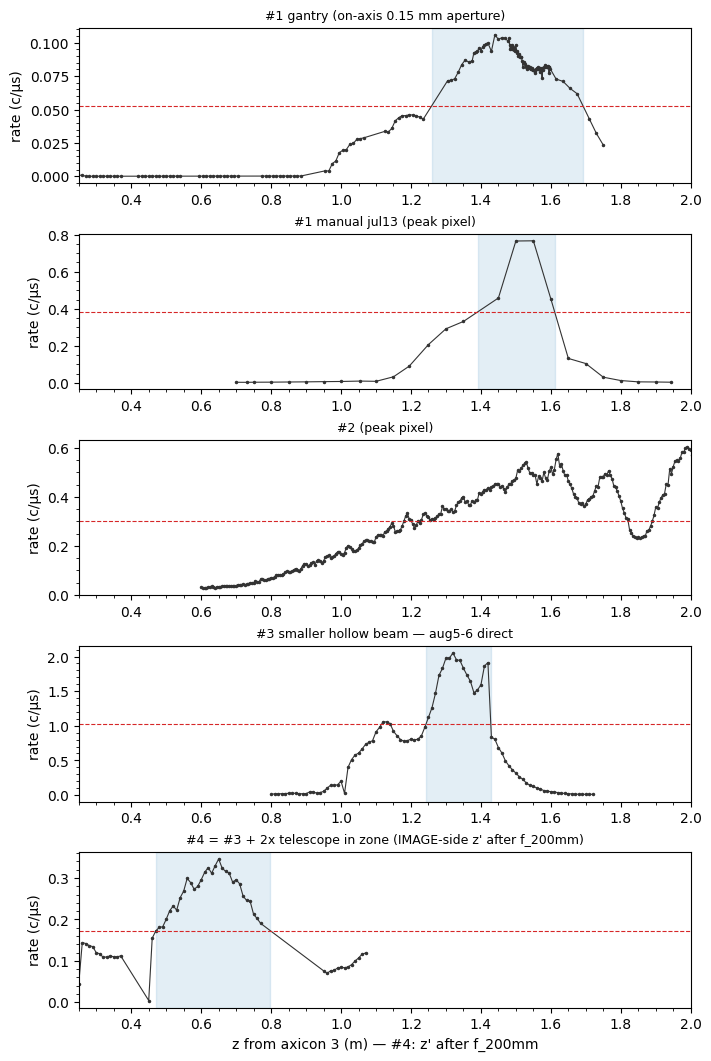

In [3]:
# --- envelope + window overview (sanity check of the crossings) --------------
fig, axes = plt.subplots(len(ENV), 1, figsize=(7, 2.1 * len(ENV)),
                         sharex=False, layout="constrained")
for ax, (label, (ys, I, w, _)) in zip(axes, ENV.items()):
    ax.plot(ys / 100, I, ".-", ms=3, lw=0.8, color="0.2")
    ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None and w["hi"] is not None:
        ax.axvspan(w["lo"] / 100, w["hi"] / 100, color="tab:blue", alpha=0.12)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel("rate (c/µs)")
    ax.set_xlim(0.25, 2.0)
    ax.minorticks_on()
axes[-1].set_xlabel("z from axicon 3 (m) — #4: z' after f_200mm")
save_fig("measured_window_envelopes")
plt.show()

## Fits-based measured windows (absolutely scaled J$_0^2$ amplitudes)

Same windows, better estimator: instead of the raw peak-pixel rate, the axial
envelope is the fitted central-lobe amplitude $A/T$ (counts/µs) from a radial
J$_0^2$ fit to each cached core thumbnail — robust to hot pixels and pixel
sampling, with per-point 1$\sigma$ errors and an rms/A quality cut
(`rms_r <= 0.06`, same as the central-lobe notebooks). Inputs are the existing
thumbnail caches; candidate #1 has no thumbnail cache, so it keeps the
peak-pixel/aperture result above.

Because the jul29 dips at ~1.70/1.85 m are real (they reproduce in the aug3
re-scan), the from-peak FWHM still degenerates for #2 — so both definitions
are printed: **from-peak** (walk out from the peak, comparable to the QDHT
column's definition) and **outermost 50\% crossings** with the deepest
in-window ripple quoted alongside. For profiles without sub-half ripple the
two coincide.

In [4]:
# --- fits-based axial envelopes + both window definitions --------------------
# 1. per dataset: join thumbnail cache -> core-frame CSV (exposure, n_sat_px);
#    fills-the-square filter (any NaN in crop = clipped -> skip)
# 2. per thumb: sub-pixel centroid, azimuthal-mean radial profile, fit
#    A*J0^2(k u) + C over |u| <= fit_half; keep k in 0.2-4x ideal_eff
# 3. per y: envelope = max A/T among clean fits (rms/A <= 0.06)
# 4. windows: from-peak FWHM (comparable to the model column) AND outermost
#    50% crossings + deepest in-window ripple
from scipy.optimize import curve_fit
from scipy.special import j0
from simulator.qdht_axicon import axicon_kr

KR3 = axicon_kr(0.5)
RMS_OK = 0.06


def j0sq(u_um, A, k, C):
    return A * j0(k * u_um * 1e-6) ** 2 + C


def radial_profile(t, um_per_px):
    # sub-pixel centroid: 3x3-mean argmax, then intensity-weighted in +-7 px
    s = t.copy()
    s[1:-1, 1:-1] = (t[:-2, :-2] + t[:-2, 1:-1] + t[:-2, 2:] +
                     t[1:-1, :-2] + t[1:-1, 1:-1] + t[1:-1, 2:] +
                     t[2:, :-2] + t[2:, 1:-1] + t[2:, 2:]) / 9.0
    iy, ix = np.unravel_index(np.argmax(s), s.shape)
    y0, y1 = max(iy - 7, 0), min(iy + 8, t.shape[0])
    x0, x1 = max(ix - 7, 0), min(ix + 8, t.shape[1])
    w = t[y0:y1, x0:x1]
    yy, xx = np.mgrid[y0:y1, x0:x1]
    cy, cx = (w * yy).sum() / w.sum(), (w * xx).sum() / w.sum()
    yy, xx = np.mgrid[:t.shape[0], :t.shape[1]]
    r_px = np.hypot(yy - cy, xx - cx)
    nb_ = np.round(r_px * 2).astype(int)  # half-pixel bins
    prof = np.bincount(nb_.ravel(), t.ravel()) / np.bincount(nb_.ravel())
    u_um = np.arange(len(prof)) * 0.5 * um_per_px
    return u_um, prof


def fit_thumb(t, um_per_px, k_ideal_eff, fit_half_um):
    u, I = radial_profile(t.astype(np.float32), um_per_px)
    ok = np.isfinite(I) & (u <= fit_half_um)
    p0 = [np.nanmax(I[ok]), k_ideal_eff, 0.0]
    popt, pcov = curve_fit(j0sq, u[ok], I[ok], p0=p0,
                           bounds=([0, 0.2 * k_ideal_eff, -np.inf],
                                   [np.inf, 4.0 * k_ideal_eff, np.inf]))
    resid = I[ok] - j0sq(u[ok], *popt)
    return popt, np.sqrt(np.diag(pcov)), np.sqrt(np.mean(resid**2)) / popt[0]


def window_outer(ys, I):
    i = int(np.argmax(I))
    half = 0.5 * I[i]
    above = I >= half
    lo = hi = None
    j = int(np.argmax(above))                  # first above-half sample
    if j > 0:
        lo = np.interp(half, [I[j - 1], I[j]], [ys[j - 1], ys[j]])
    j = len(I) - 1 - int(np.argmax(above[::-1]))   # last above-half sample
    if j < len(I) - 1:
        hi = np.interp(half, [I[j + 1], I[j]], [ys[j + 1], ys[j]])
    inw = (ys >= (lo or ys[0])) & (ys <= (hi or ys[-1]))
    ripple = I[inw].min() / I[i] if inw.any() else np.nan
    return dict(half=half, lo=lo, hi=hi, ripple=ripple, y_peak=ys[i], peak=I[i])


def exposures(csv_path):
    d = {}
    for r in csv.DictReader(open(csv_path)):
        if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0:
            d[(r["run"], r["frame"])] = float(r["exposure_us"])
    return d


# One dict per dataset:
#   candidate_id - report candidate number (int; keys of PANEL_XLIM etc.)
#   label        - candidate name (report label; keys of FIT_ENV)
#   thumbs_npz   - cached core thumbnails (reductions/)
#   frames_csv   - core-frame CSV with per-frame exposure_us / n_sat_px
#   frame_prefix - keep only frames whose name starts with these placement
#                  prefixes; None = keep all (cache holds a single dataset).
#                  Needed for the aug6 caches, whose CSVs contain BOTH the
#                  direct and telescope placement families.
#   um_per_px    - thumbnail pixel pitch in um (fallback; the npz value wins)
#   fit_half_um  - radial J0^2 fit window, |u| <= this
#   mag          - transverse magnification M (fit k bounds scale as
#                  k_ideal/M; 2.0 for the in-zone telescope, else 1.0)
#   excluded_runs- run names dropped before fitting
FITSETS = (
    dict(candidate_id=1, label="Candidate #1 (Jul 22-23)",
         thumbs_npz="ax3_core_thumbs_2026_07_23.npz",
         frames_csv="ax3_core_frames_2026_07_23.csv",
         frame_prefix=None, um_per_px=6.9, fit_half_um=450.0, mag=1.0,
         excluded_runs=set()),
    dict(candidate_id=2, label="Candidate #2 (Jul 29-30)",
         thumbs_npz="ax3_core_thumbs.npz",
         frames_csv="ax3_core_frames.csv",
         frame_prefix=None, um_per_px=6.9, fit_half_um=450.0, mag=1.0,
         excluded_runs={"auto_scan-2026-07-29_13-03-58"}),
    dict(candidate_id=3, label="Candidate #3 (Aug 5-6)",
         thumbs_npz="ax3_core_thumbs_2026_08_06.npz",
         frames_csv="ax3_core_frames_2026_08_06.csv",
         frame_prefix=("aug5_axicon3", "aug6_axicon3"),
         um_per_px=6.9, fit_half_um=450.0, mag=1.0,
         # match telescope_vs_axicon3_comparison's EXCLUDED: 10-59-06 is the
         # superseded first 012 run (y 130-142, re-scanned as 13-33-08).
         # NB the CSV's excluded_run column is STALE for it (incremental
         # cache never back-fills flags on existing rows) — hence explicit.
         excluded_runs={"auto_scan-2026-08-06_10-59-06"}),
    dict(candidate_id=4, label="Candidate #4 (Aug 6)",
         thumbs_npz="telescope_core_thumbs_2026_08_06.npz",
         frames_csv="telescope_core_frames_2026_08_06.csv",
         frame_prefix=("aug6_telescope",),
         um_per_px=13.8, fit_half_um=900.0, mag=2.0, excluded_runs=set()),
)

# label -> candidate_id lookup for downstream cells (labels are pure
# display text; never parse them)
CANDIDATE_ID = {ds["label"]: ds["candidate_id"] for ds in FITSETS}

FIT_ENV = {}
for ds in FITSETS:
    name, pref = ds["label"], ds["frame_prefix"]
    fit_half, excl = ds["fit_half_um"], ds["excluded_runs"]
    z = np.load(RED / ds["thumbs_npz"], allow_pickle=True)
    um_px = (float(z["um_per_px"]) if "um_per_px" in z.files
             else ds["um_per_px"])
    T_exp = exposures(RED / ds["frames_csv"])
    k_eff = KR3 / ds["mag"]
    best = {}
    n_nan = n_noexp = n_fail = 0
    for t, y, run, fr in zip(z["thumbs"], z["ys_cm"], z["runs"], z["frames"]):
        if pref and not str(fr).startswith(pref):
            continue
        if str(run) in excl:
            continue
        if np.isnan(np.asarray(t, dtype=np.float32)).any():
            n_nan += 1
            continue
        T = T_exp.get((str(run), str(fr)))
        if T is None:
            n_noexp += 1  # saturated/excluded per CSV, or cache/CSV drift
            continue
        try:
            (A, k, C), perr, rms = fit_thumb(np.asarray(t), um_px, k_eff, fit_half)
        except RuntimeError:
            n_fail += 1
            continue
        if rms > RMS_OK:
            continue
        rate, err = A / T, perr[0] / T
        yy = float(y)
        if yy not in best or rate > best[yy][0]:
            best[yy] = (rate, err)
    ys = np.array(sorted(best))
    I = np.array([best[y][0] for y in ys])
    E = np.array([best[y][1] for y in ys])
    print(f"{name}: {len(ys)} y points "
          f"(skipped: {n_nan} clipped, {n_noexp} no-CSV/sat, {n_fail} no-fit)")
    report(f"  from-peak: {name}", ys, I)
    w = window_outer(ys, I)
    lo = "?" if w["lo"] is None else f"{w['lo'] / 100:.2f}"
    hi = "?" if w["hi"] is None else f"{w['hi'] / 100:.2f}"
    if w["lo"] is not None and w["hi"] is not None:
        span = f"{(w['hi'] - w['lo']) / 100:.2f} ($z \\in [{lo}, {hi}]$)"
    else:
        span = f"UNBOUNDED [{lo}, {hi}] — scan span [{ys[0]/100:.2f}, {ys[-1]/100:.2f}] m"
    print(f"  outermost 50%: {span}   deepest in-window ripple "
          f"{100 * w['ripple']:.0f}% of peak\n")
    FIT_ENV[name] = (ys, I, E, w)

/tmp/ipykernel_2533/3412358613.py:36: RuntimeWarning: invalid value encountered in divide
  prof = np.bincount(nb_.ravel(), t.ravel()) / np.bincount(nb_.ravel())


Candidate #1 (Jul 22-23): 157 y points (skipped: 402 clipped, 0 no-CSV/sat, 1 no-fit)
  NOTE upper crossing interpolated across a 4 cm data gap [1.68, 1.71] m
  from-peak: Candidate #1 (Jul 22-23)
  peak 0.723 c/us at 1.48 m   ->  0.38 ($z \in [1.29, 1.68]$)
{'y_peak': np.float64(148.0), 'peak': np.float64(0.7226031348444812), 'half': np.float64(0.3613015674222406), 'lo': np.float64(129.43983852717054), 'hi': np.float64(167.7353287062657), 'dips': []}
  outermost 50%: 0.38 ($z \in [1.29, 1.68]$)   deepest in-window ripple 52% of peak



Candidate #2 (Jul 29-30): 272 y points (skipped: 320 clipped, 0 no-CSV/sat, 0 no-fit)
  from-peak: Candidate #2 (Jul 29-30)
  peak 0.59 c/us at 1.99 m   ->  UNBOUNDED [1.89, ?] — scan span [0.60, 2.01] m
{'y_peak': np.float64(198.5), 'peak': np.float64(0.5903458875935176), 'half': np.float64(0.2951729437967588), 'lo': np.float64(188.93495277728667), 'hi': None, 'dips': []}
  outermost 50%: UNBOUNDED [1.18, ?] — scan span [0.60, 2.01] m   deepest in-window ripple 37% of peak



Candidate #3 (Aug 5-6): 83 y points (skipped: 49 clipped, 3 no-CSV/sat, 0 no-fit)
  from-peak: Candidate #3 (Aug 5-6)
  peak 2 c/us at 1.32 m   ->  0.17 ($z \in [1.24, 1.42]$)
{'y_peak': np.float64(132.0), 'peak': np.float64(2.0029777455651914), 'half': np.float64(1.0014888727825957), 'lo': np.float64(124.34452974819868), 'hi': np.float64(141.81511696872172), 'dips': []}
  outermost 50%: 0.30 ($z \in [1.12, 1.42]$)   deepest in-window ripple 37% of peak



Candidate #4 (Aug 6): 60 y points (skipped: 115 clipped, 0 no-CSV/sat, 0 no-fit)
  NOTE upper crossing interpolated across a 18 cm data gap [0.77, 0.95] m
  from-peak: Candidate #4 (Aug 6)
  peak 0.323 c/us at 0.65 m   ->  0.32 ($z \in [0.47, 0.79]$)
{'y_peak': np.float64(65.0), 'peak': np.float64(0.322767691046132), 'half': np.float64(0.161383845523066), 'lo': np.float64(46.8965803900741), 'hi': np.float64(78.5216316032488), 'dips': []}
  outermost 50%: 0.32 ($z \in [0.47, 0.79]$)   deepest in-window ripple 50% of peak



saved images/final_report_calcs_2026_08_10/measured_window_envelopes_fits.png


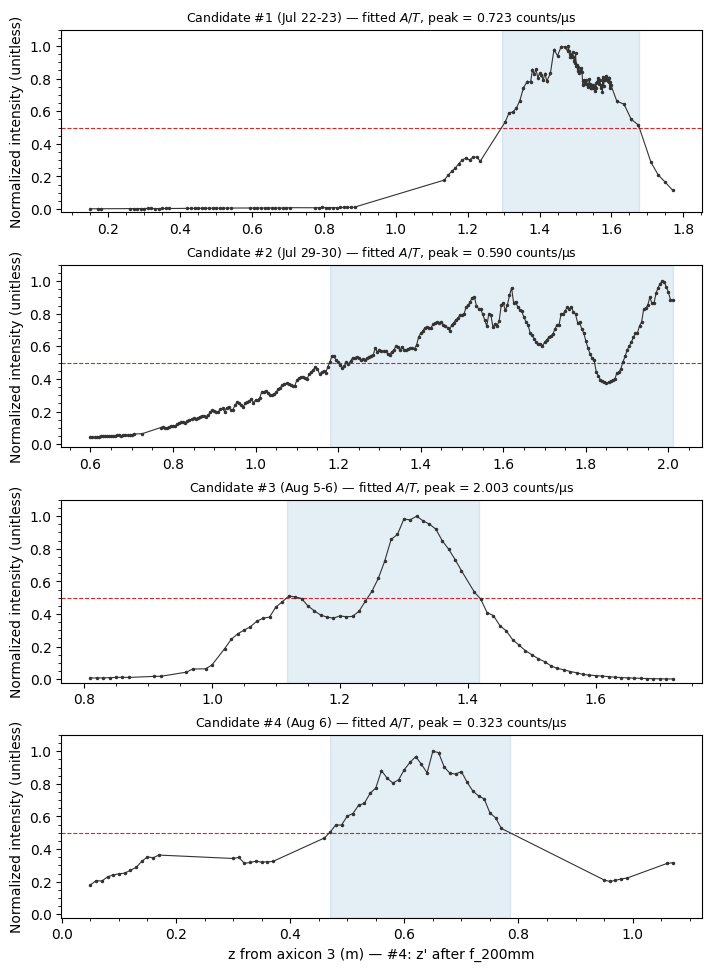

In [5]:
# --- fits-based envelopes: both window definitions overlaid ------------------
# Each panel normalized to ITS OWN peak — the window is defined relative to
# the peak anyway (edges at 50%), so I/I_peak puts the threshold at exactly
# 0.5 everywhere and makes the four window SHAPES directly comparable on one
# [0, 1] axis. Absolute rates are not cross-comparable between candidates
# (different beams/calibrations/telescope), so each panel quotes its own
# peak (c/us) as the photometric anchor.
fig, axes = plt.subplots(len(FIT_ENV), 1, figsize=(7, 2.4 * len(FIT_ENV)),
                         sharey=True, layout="constrained")
for ax, (label, (ys, I, E, w)) in zip(np.atleast_1d(axes), FIT_ENV.items()):
    pk = w["peak"]
    ax.errorbar(ys / 100, I / pk, yerr=E / pk, fmt=".-", ms=3, lw=0.8,
                color="0.2", elinewidth=0.6)
    ax.axhline(0.5, color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None or w["hi"] is not None:
        ax.axvspan((w["lo"] or ys[0]) / 100, (w["hi"] or ys[-1]) / 100,
                   color="tab:blue", alpha=0.12)
    ax.set_title(label + f" — fitted $A/T$, peak = {pk:.3f} counts/µs", fontsize=9)
    ax.set_ylabel("Normalized intensity (unitless)")
    ax.set_ylim(-0.02, 1.10)
    ax.minorticks_on()
np.atleast_1d(axes)[-1].set_xlabel("z from axicon 3 (m) — #4: z' after f_200mm")
save_fig("measured_window_envelopes_fits")
plt.show()

cut at dip trough y = 1.85 m (envelope 0.220 c/us there); 240/272 points kept

#2 MAIN PLATEAU (final peak excluded)
  peak 0.566 c/us at 1.62 m   ->  0.61 ($z \in [1.21, 1.82]$)
{'y_peak': np.float64(162.0), 'peak': np.float64(0.5661182534365976), 'half': np.float64(0.2830591267182988), 'lo': np.float64(121.4543871045252), 'hi': np.float64(182.26243484760246), 'dips': []}
  outermost 50%: 0.65 ($z \in [1.18, 1.82]$)   deepest in-window ripple 49% of peak


saved images/final_report_calcs_2026_08_10/cand2_window_no_final_peak.png


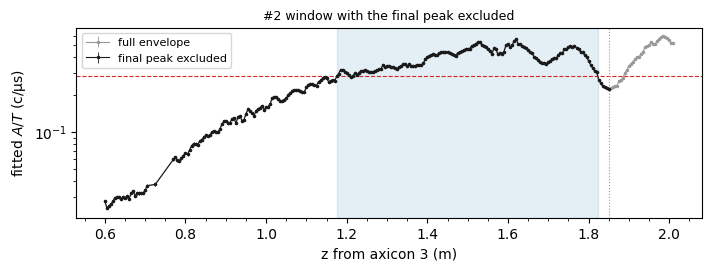

In [6]:
# --- #2 variant: exclude the final peak, re-derive the window ----------------
# Rationale to weigh: the final rise (peak 0.59 c/us at 1.99 m) sits right
# where QDHT puts the window peak (~1.88 m) and is cut off by the scan end at
# 2.01 m, so the full-envelope window is unbounded above. Cutting the
# envelope at the dip trough before the final rise gives the bounded window
# of the MAIN PLATEAU instead. Quote it only as such — it deliberately
# understates the full window.
ys2, I2, E2, _ = FIT_ENV["Candidate #2 (Jul 29-30)"]

m = (ys2 >= 175) & (ys2 <= 199)               # bracket the last dip trough
y_cut = ys2[m][np.argmin(I2[m])]
keep = ys2 <= y_cut
print(f"cut at dip trough y = {y_cut / 100:.2f} m "
      f"(envelope {I2[m].min():.3f} c/us there); "
      f"{keep.sum()}/{len(ys2)} points kept\n")

report("#2 MAIN PLATEAU (final peak excluded)", ys2[keep], I2[keep])
w = window_outer(ys2[keep], I2[keep])
lo = "?" if w["lo"] is None else f"{w['lo'] / 100:.2f}"
hi = "?" if w["hi"] is None else f"{w['hi'] / 100:.2f}"
length = "" if None in (w["lo"], w["hi"]) else f"{(w['hi'] - w['lo']) / 100:.2f} "
print(f"  outermost 50%: {length}($z \\in [{lo}, {hi}]$)   "
      f"deepest in-window ripple {100 * w['ripple']:.0f}% of peak")

fig, ax = plt.subplots(figsize=(7, 2.6), layout="constrained")
ax.errorbar(ys2 / 100, I2, yerr=E2, fmt=".-", ms=3, lw=0.8, color="0.6",
            elinewidth=0.6, label="full envelope")
ax.errorbar(ys2[keep] / 100, I2[keep], yerr=E2[keep], fmt=".-", ms=3, lw=0.8,
            color="0.1", elinewidth=0.6, label="final peak excluded")
ax.axhline(w["half"], color="tab:red", lw=0.8, ls="--")
if w["lo"] is not None and w["hi"] is not None:
    ax.axvspan(w["lo"] / 100, w["hi"] / 100, color="tab:blue", alpha=0.12)
ax.axvline(y_cut / 100, color="tab:orange", lw=0.8, ls=":")
ax.set_xlabel("z from axicon 3 (m)")
ax.set_ylabel("fitted $A/T$ (c/µs)")
ax.set_yscale("log")
ax.minorticks_on()
ax.legend(fontsize=8)
ax.set_title("#2 window with the final peak excluded", fontsize=9)
save_fig("cand2_window_no_final_peak")
plt.show()

## Placement / drift comparison figure (report)

Self-contained port of the `placement_cmp_report` cell from
`axicon3_placement_comparison_2026_08_03`: candidate #2's placement 009
measured on jul29 (run 15-56-42) vs its aug3 re-placement (runs 15-06-23 +
15-31-36), at z = 175 and 179 cm. One figure showing fit quality
(rms/A ≲ 1%), reproducibility of the $k_r$ anomaly across an independent
re-alignment, the aug3 $k_x$-$k_y$ split (astigmatism), and 5-day amplitude
drift. Everything is normalized to the single global peak (brightest fitted
amplitude among the picks), so the axis is [0, 1] but all panels share one
absolute scale.

**Report axis convention** (differs from the gantry/dataset naming): x =
horizontal image axis, y = vertical image axis, z = propagation. The dataset
calls those x, z, y respectively.

Inputs are `reductions/placement_cmp_core_thumbs.npz` +
`placement_cmp_dark_stats.csv`; per-frame y/exposure comes from the runs'
`frames.jsonl` when `profiler/data` is present and is cached to
`reductions/placement_cmp_frame_info.csv` for cache-only reruns.

{(175, 'jul29'): ('auto_scan-2026-07-29_15-56-42', np.float64(0.484)), (180, 'jul29'): ('auto_scan-2026-07-29_15-56-42', np.float64(0.376)), (175, 'aug3'): ('auto_scan-2026-08-03_15-31-36', np.float64(0.334)), (180, 'aug3'): ('auto_scan-2026-08-03_15-31-36', np.float64(0.333))}


global peak G = 0.484 c/us (auto_scan-2026-07-29_15-56-42)


/tmp/ipykernel_2533/35739592.py:181: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0.5, h_pad=0.5, w_pad=2, rect=[0.035, 0.0, 1.0, 0.93])


saved images/final_report_calcs_2026_08_10/placement_cmp_report.png


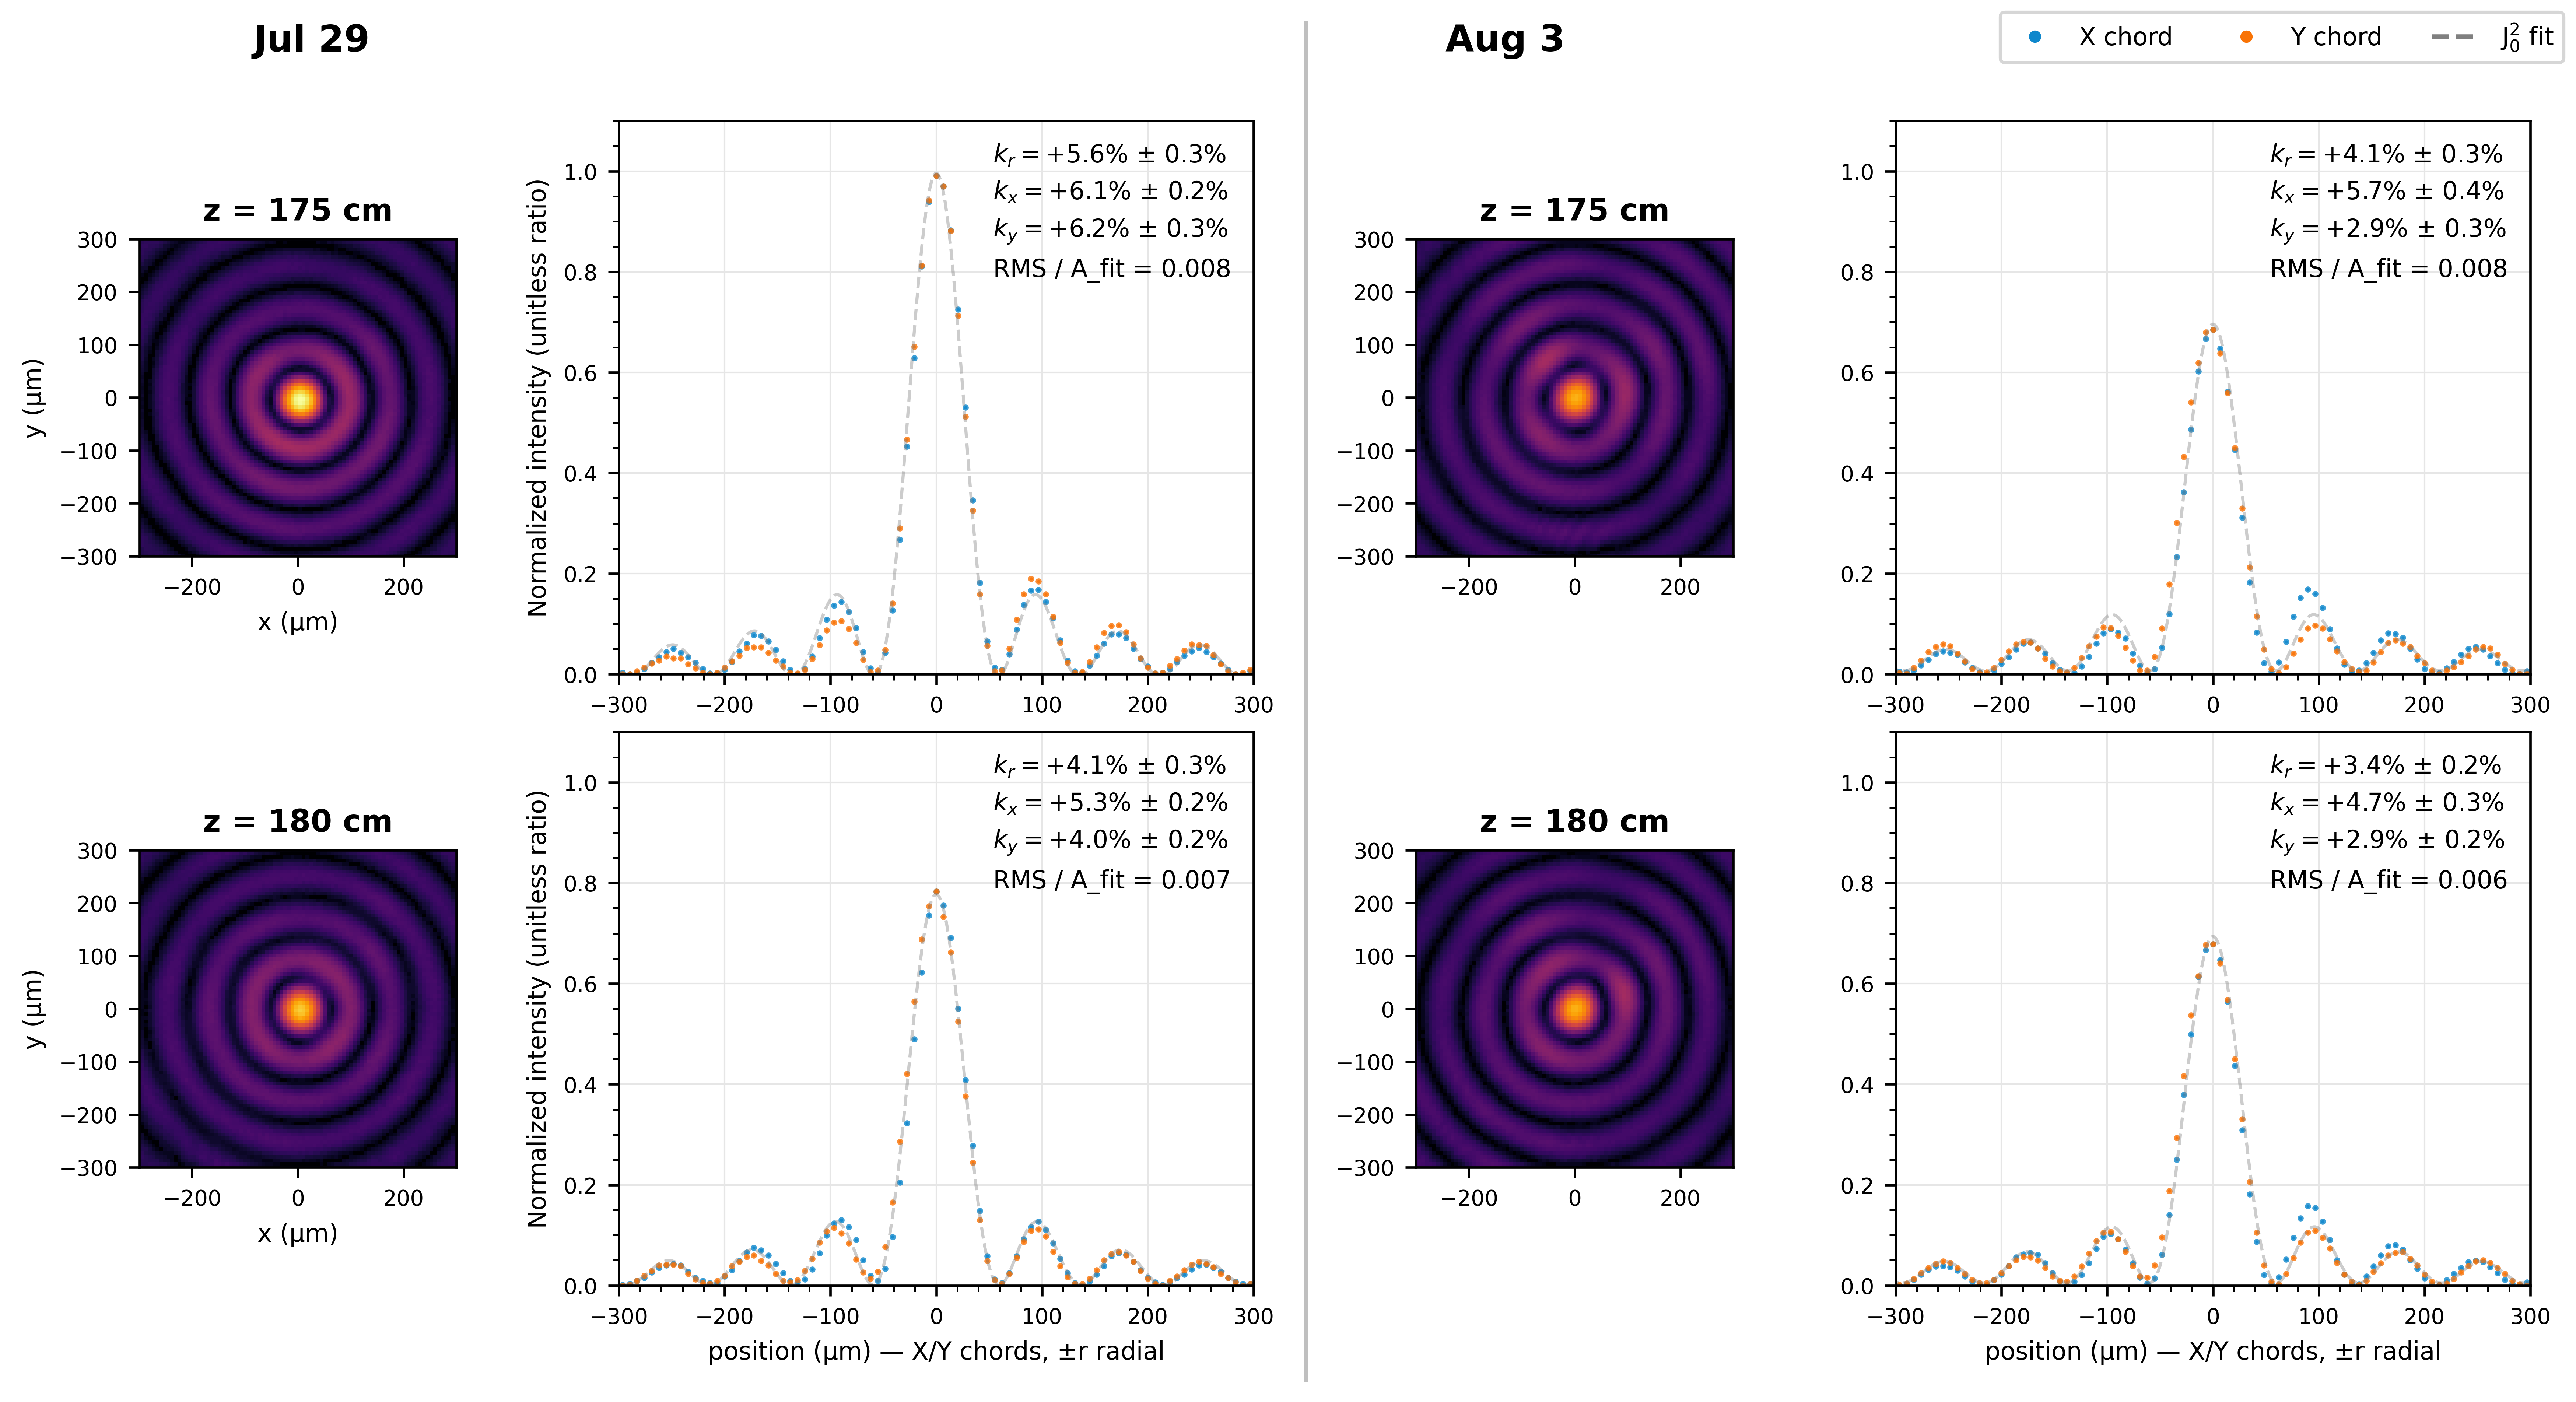

In [7]:
# --- placement/drift comparison (candidate #2, jul29 vs aug3) ----------------
# 1. per-frame info (y, exposure, slice, n_sat_px) from frames.jsonl,
#    cached to placement_cmp_frame_info.csv
# 2. rate thumbnails (I - I_dark_slice)/T from the placement thumb cache
# 3. per (z row, day): pick the largest-radial-A unsaturated, fully-filled
#    frame at that y; fits identical to the placement notebook — radial
#    (azimuthal mean about the 5x5 sub-pixel centroid, u0 = 0) and X/Y
#    chords (free center, |u0| <= 35 um), k bounded 0.5-1.5x ideal,
#    1-sigma errors = sqrt(diag(pcov))
# NB aug3 needs BOTH runs for rows 175/180: 15-06-23 is the aborted start
# (y 170-173.5 only); the re-anchored 15-31-36 (y 173-180) is where the
# 175/180 cm frames live. PC_RUNS genuinely filters the candidates below.
PC_RUNS = {"jul29": ["auto_scan-2026-07-29_15-56-42"],
           "aug3": ["auto_scan-2026-08-03_15-06-23",
                    "auto_scan-2026-08-03_15-31-36"]}
PC_RUN_SET = {r for rr in PC_RUNS.values() for r in rr}
ROWS_RPT = [175, 180]
PC_INFO_CSV = RED / "placement_cmp_frame_info.csv"
PC_FIT_HALF = 450.0
PC_UM_PX = 6.9


def pc_j0sq(u_um, A, k, u0_um, Cc):
    return A * j0(k * (u_um - u0_um) * 1e-6) ** 2 + Cc


def pc_fit(u_um, I, free_center):
    ok = np.isfinite(I) & (np.abs(u_um) <= PC_FIT_HALF)
    u0m = 35.0 if free_center else 1e-9
    popt, pcov = curve_fit(pc_j0sq, u_um[ok], I[ok],
                           p0=[np.nanmax(I[ok]), KR3, 0.0, 0.0],
                           bounds=([0, 0.5 * KR3, -u0m, -np.inf],
                                   [np.inf, 1.5 * KR3, u0m, np.inf]))
    resid = I[ok] - pc_j0sq(u_um[ok], *popt)
    return popt, np.sqrt(np.diag(pcov)), np.sqrt(np.mean(resid**2)) / popt[0]


if not PC_INFO_CSV.exists():
    rows_i = []
    for day, runs_ in PC_RUNS.items():
        for run in runs_:
            mf = REPO / "profiler/data" / run / "frames.jsonl"
            for ln, line in enumerate(open(mf)):
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    print(f"WARNING {run}: bad manifest line {ln} skipped")
                    continue
                ex = rec.get("Extra", {})
                if (ex.get("ScanKind") != "AutoBeamStack"
                        or Path(rec["Path"]).stem.endswith("-dark")):
                    continue
                rows_i.append(dict(day=day, run=run,
                                   frame=Path(rec["Path"]).name,
                                   slice=ex["Subfolder"],
                                   y_cm=ex["BeamY_mm"] / 10.0,
                                   exposure_us=ex["Exposure_us"],
                                   n_sat_px=rec.get("SaturatedPixelCount", 0)))
    with open(PC_INFO_CSV, "w", newline="") as fo:
        w = csv.DictWriter(fo, fieldnames=list(rows_i[0]))
        w.writeheader(); w.writerows(rows_i)
    print(f"built {PC_INFO_CSV.name}: {len(rows_i)} frames")
PC_INFO = {(r["run"], r["frame"]): r for r in csv.DictReader(open(PC_INFO_CSV))}
PC_DARK = {(r["run"], r["slice"]): float(r["dark_mean"])
           for r in csv.DictReader(open(RED / "placement_cmp_dark_stats.csv"))}

_z = np.load(RED / "placement_cmp_core_thumbs.npz", allow_pickle=True)
pc_cands = []
for t, run, fr in zip(_z["thumbs"], _z["runs"], _z["frames"]):
    if str(run) not in PC_RUN_SET:
        continue
    inf = PC_INFO.get((str(run), str(fr)))
    if inf is None or int(inf["n_sat_px"]) > 0:
        continue
    t32 = np.asarray(t, dtype=np.float32)
    if np.isnan(t32).any():
        continue
    y_cm = float(inf["y_cm"])
    if min(abs(y_cm - y0) for y0 in ROWS_RPT) > 0:
        continue
    rt = ((t32 - PC_DARK.get((str(run), inf["slice"]), 0.0))
          / float(inf["exposure_us"]))
    # 5x5 sub-pixel centroid about the peak -> radial profile (1-px bins)
    py, px_ = np.unravel_index(np.nanargmax(rt), rt.shape)
    w = rt[max(py - 2, 0):py + 3, max(px_ - 2, 0):px_ + 3]
    wy, wx = np.mgrid[max(py - 2, 0):py + 3, max(px_ - 2, 0):px_ + 3]
    cy, cx = (w * wy).sum() / w.sum(), (w * wx).sum() / w.sum()
    yy, xx = np.mgrid[:rt.shape[0], :rt.shape[1]]
    r_um = np.hypot(yy - cy, xx - cx) * PC_UM_PX
    b = (r_um / PC_UM_PX).astype(int)
    prof = np.bincount(b.ravel(), rt.ravel()) / np.maximum(np.bincount(b.ravel()), 1)
    r_cent = (np.arange(len(prof)) + 0.5) * PC_UM_PX
    x_u = (np.arange(rt.shape[1]) - px_) * PC_UM_PX
    z_u = (np.arange(rt.shape[0]) - py) * PC_UM_PX
    try:
        pr, er, rms_r = pc_fit(r_cent, prof, free_center=False)
        pxc, exc, _ = pc_fit(x_u, rt[py, :], free_center=True)
        pzc, ezc, _ = pc_fit(z_u, rt[:, px_], free_center=True)
    except RuntimeError:
        continue
    pc_cands.append(dict(day=str(inf["day"]), run=str(run), frame=str(fr),
                         y=y_cm, rt=rt, r=r_cent, Ir=prof, x_u=x_u,
                         Ix=rt[py, :], z_u=z_u, Iz=rt[:, px_],
                         pr=pr, pr_err=er, rms_r=rms_r,
                         px=pxc, px_err=exc, pz=pzc, pz_err=ezc))

pc_picks = {}
for c in pc_cands:
    key = (int(c["y"]), c["day"])
    if key not in pc_picks or c["pr"][0] > pc_picks[key]["pr"][0]:
        pc_picks[key] = c
print({k: (v["run"], round(v["pr"][0], 3)) for k, v in pc_picks.items()})

G = max(f["pr"][0] for f in pc_picks.values())   # global peak (fitted A)
u_fine = np.linspace(-PC_FIT_HALF, PC_FIT_HALF, 500)
cmap_pc = plt.get_cmap("inferno").copy()
cmap_pc.set_bad("0.25")

# layout: per row, image+fit pairs interleaved per day —
# [jul29 image, jul29 fit, aug3 image, aug3 fit]
fig, axes = plt.subplots(len(ROWS_RPT), 4, figsize=(12, 3.1 * len(ROWS_RPT)),
                         squeeze=False, width_ratios=[1, 2,1, 2],
                         layout="constrained", dpi=600)
for idx, (y0, (ax_i1, ax_p1, ax_i2, ax_p2)) in enumerate(zip(ROWS_RPT, axes)):
    for day, lab, ax_im, ax_pr in (("jul29", "Jul 29", ax_i1, ax_p1),
                                   ("aug3", "Aug 3", ax_i2, ax_p2)):
        f = pc_picks[(y0, day)]
        ax_im.imshow(np.sqrt(np.clip(f["rt"] / G, 0, 1)), cmap=cmap_pc,
                     vmin=0, vmax=1, interpolation="nearest",
                     extent=[-497, 497, -497, 497])
        # day / z live in the figure-level group labels below
        if day == "jul29":
            ax_im.set_xlabel("x (µm)", fontsize=8)
            ax_im.set_ylabel("y (µm)", fontsize=8)
        ax_im.tick_params(labelsize=7)
        ax_im.set_title(f"z = {f['y']:.0f} cm", fontsize=10, fontweight="bold")
        ax_im.set_xlim(-300, 300)
        ax_im.set_ylim(-300, 300)

        ax_pr.plot(f["x_u"], f["Ix"] / G, ".", ms=2, color="xkcd:water blue", alpha=0.8)
        ax_pr.plot(f["z_u"], f["Iz"] / G, ".", ms=2, color="xkcd:orange", alpha=0.8)
        # ax_pr.plot(f["r"], f["Ir"] / G, "-", color="0.2", lw=0.9)
        # ax_pr.plot(-f["r"], f["Ir"] / G, "-", color="0.2", lw=0.9)
        ax_pr.plot(u_fine, pc_j0sq(u_fine, *f["pr"]) / G, ls="--",
                   color="grey", lw=1, alpha=0.40)
        ax_pr.set_xlim(-300, 300)
        ax_pr.set_ylim(0, 1.10)
        krdev = f["pr"][1] / KR3 - 1
        krerr = f["pr_err"][1] / KR3
        # dataset z axis = report y axis (see md note above)
        kxdev, kxerr = f["px"][1] / KR3 - 1, f["px_err"][1] / KR3
        kydev, kyerr = f["pz"][1] / KR3 - 1, f["pz_err"][1] / KR3
        if day == "jul29":
            ax_pr.set_ylabel("Normalized intensity (unitless ratio)", fontsize=8)
        ax_pr.legend(handles=[
            plt.Line2D([], [], ls="", label=f"$k_r=${krdev:+.1%} ± {krerr:.1%}"),
            plt.Line2D([], [], ls="", label=f"$k_x=${kxdev:+.1%} ± {kxerr:.1%}"),
            plt.Line2D([], [], ls="", label=f"$k_y=${kydev:+.1%} ± {kyerr:.1%}"),
            plt.Line2D([], [], ls="", label=f"RMS / A_fit = {f['rms_r']:.3f}"),

        ], loc="upper right", fontsize=8, frameon=False
        )
        ax_pr.tick_params(labelsize=7)
        ax_pr.minorticks_on()
        ax_pr.grid(True, which="major", color="0.9", lw=0.5)
for ax in (axes[-1][1], axes[-1][3]):
    ax.set_xlabel("position (µm) — X/Y chords, ±r radial", fontsize=8)
fig.legend(handles=[
    plt.Line2D([], [], marker=".", ls="", color="xkcd:water blue", label="X chord"),
    plt.Line2D([], [], marker=".", ls="", color="xkcd:orange", label="Y chord"),
    # plt.Line2D([], [], color="0.2", label="radial mean"),
    plt.Line2D([], [], ls="--", color="grey", label="J$_0^2$ fit")],
    loc="outside upper right", fontsize=8, ncol=3)
print(f"global peak G = {G:.3f} c/us "
      f"({pc_picks[(ROWS_RPT[0], 'jul29')]['run']})")
# frame + group labels: reserve left/top margins, then place a divider
# between the day halves, bold day headers, and rotated z row labels
fig.tight_layout(pad=0.5, h_pad=0.5, w_pad=2, rect=[0.035, 0.0, 1.0, 0.93])
fig.canvas.draw()
P = [[axes[i][j].get_position() for j in range(4)]
     for i in range(len(ROWS_RPT))]
x_div = 0.49 * (max(P[i][1].x1 for i in range(len(ROWS_RPT)))
               + min(P[i][2].x0 for i in range(len(ROWS_RPT))))
y_bot = min(P[-1][j].y0 for j in range(4))
fig.add_artist(plt.Line2D([x_div, x_div], [0, 0.99],
                          transform=fig.transFigure, color="0.75", lw=1.2))
                          
fig.text(0.15, 0.99, "Jul 29", ha="center", va="top", fontsize=12,
             fontweight="bold")
fig.text(0.6, 0.99, "Aug 3", ha="center", va="top", fontsize=12,
             fontweight="bold")
# for i, y0 in enumerate(ROWS_RPT):
#     yc = 0.5 * (P[i][0].y0 + P[i][0].y1)
#     fig.text(0.006, yc, f"z = {y0} cm", rotation=90, ha="left", va="center",
#              fontsize=12, fontweight="bold")
save_fig("placement_cmp_report")
plt.show()

saved images/final_report_calcs_2026_08_10/placement_cmp_report_jul29.png


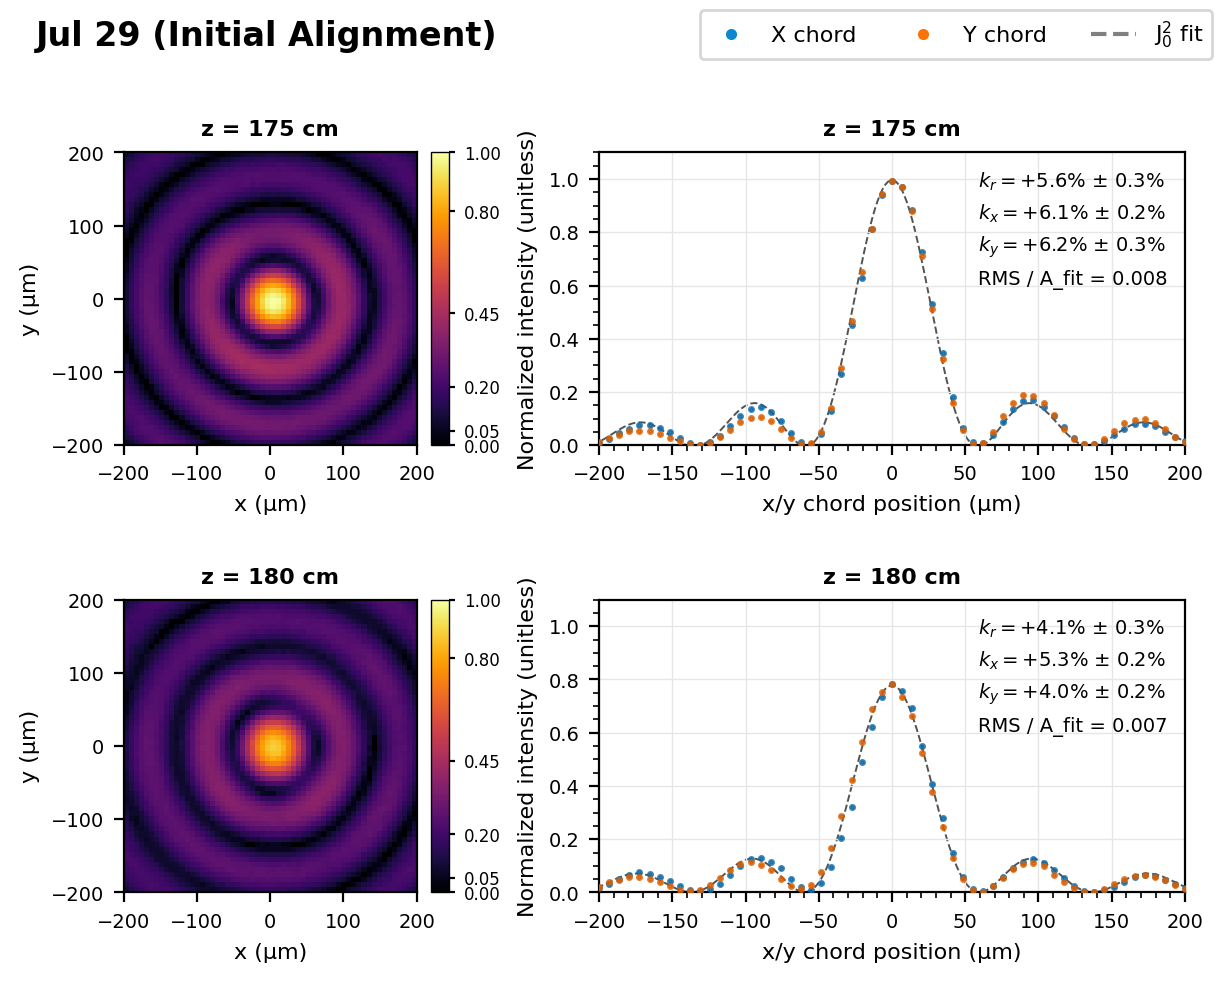

saved images/final_report_calcs_2026_08_10/placement_cmp_report_aug3.png


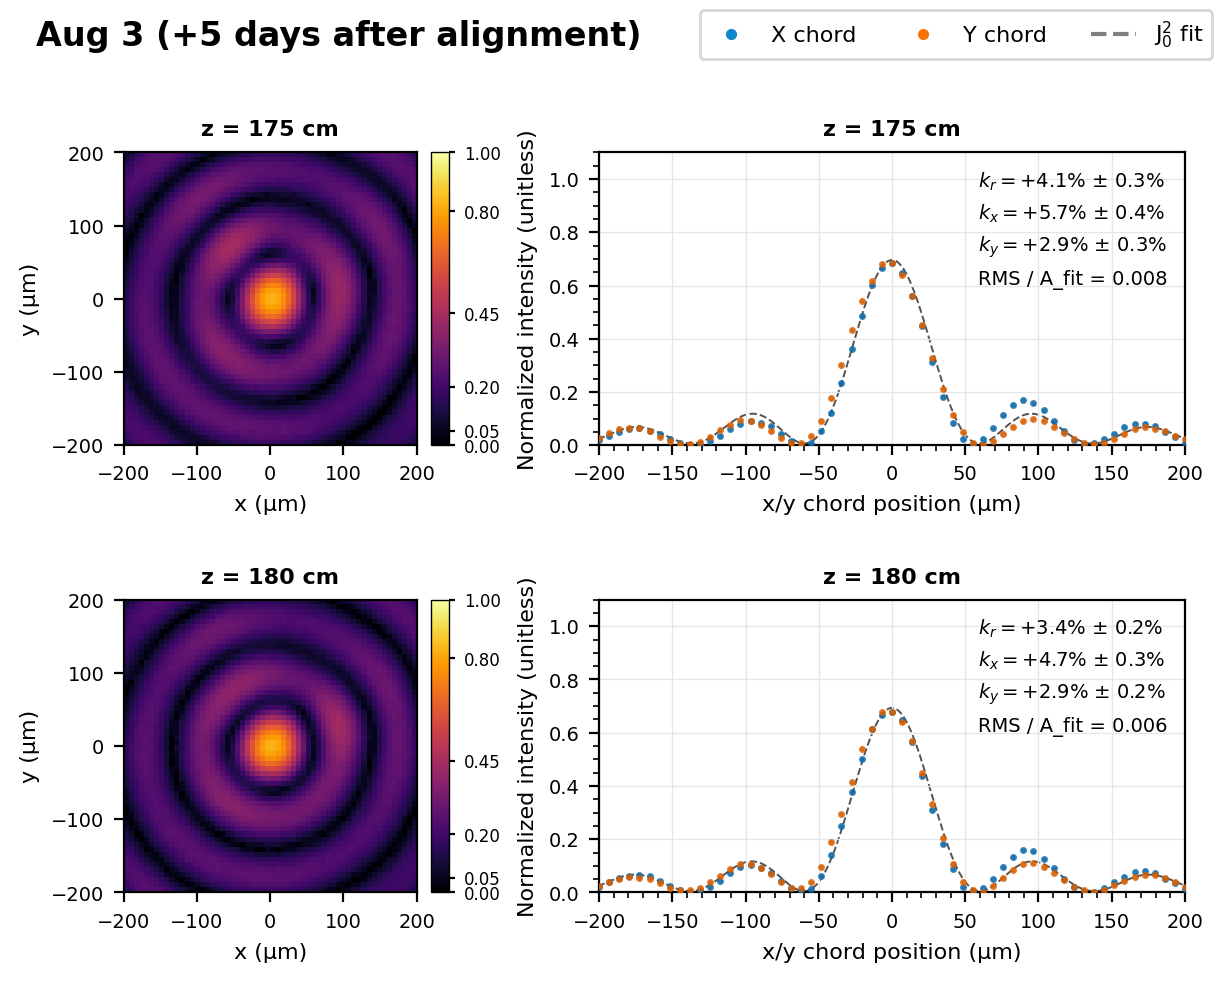

In [8]:
# --- two-figure variant: one figure per day, for side-by-side placement ------
# Same picks and the SAME global-peak normalization G as the combined figure
# above (shared across both figures, so the [0,1] scale stays absolute
# day-to-day and the Aug 3 amplitude drop remains visible). Each figure:
# 2 rows (z = 175, 180) x [image, fit], styled like the combined version,
# saved separately for LaTeX minipage/subfigure placement.
# Chord/fit legend only on the Jul 29 figure — in the paper the two sit
# side by side under one caption, so one legend serves both.
from matplotlib.legend import Legend


for day, lab in (("jul29", "Jul 29 (Initial Alignment)"), ("aug3", "Aug 3 (+5 days after alignment)")):
    fig, axes2 = plt.subplots(len(ROWS_RPT), 2, figsize=(6.0, 4.8),
                              squeeze=False, width_ratios=[1, 2],
                              layout="constrained", dpi=200)
    for y0, (ax_im, ax_pr) in zip(ROWS_RPT, axes2):
        f = pc_picks[(y0, day)]
        im = ax_im.imshow(np.sqrt(np.clip(f["rt"] / G, 0, 1)), cmap=cmap_pc,
                     vmin=0, vmax=1, interpolation="nearest",
                     extent=[-497, 497, -497, 497])
        ax_im.set_title(f"z = {f['y']:.0f} cm", fontsize=8,
                        fontweight="bold")
        ax_im.set_xlim(-200, 200)
        ax_im.set_ylim(-200, 200)
        ax_im.set_box_aspect(1)      # square image box
        ax_im.set_xlabel("x (µm)", fontsize=8)
        ax_im.set_ylabel("y (µm)", fontsize=8)
        ax_im.tick_params(labelsize=7)

        ax_pr.set_title(f"z = {f['y']:.0f} cm", fontsize=8,
                        fontweight="bold")
        ax_pr.plot(f["x_u"], f["Ix"] / G, ".", ms=3, zorder=3,
                   color="#0e6ba8", alpha=0.8)
        ax_pr.plot(f["z_u"], f["Iz"] / G, ".", ms=3, zorder=3,
                   color="#d95f02", alpha=0.8)
        ax_pr.plot(u_fine, pc_j0sq(u_fine, *f["pr"]) / G, ls="--",
                   color="0.25", lw=0.7, alpha=0.9, zorder=1)
        ax_pr.set_xlim(-200, 200)
        ax_pr.set_ylim(0, 1.10)
        # colorbar as an inset so it aligns with theimage axes without stealing
        # layout width (keeps the image/plot height match intact)
        cax = ax_im.inset_axes([1.05, 0.0, 0.06, 1.0])
        cb = fig.colorbar(im, cax=cax)
        cb.set_ticks([0, 0.05, 0.2, 0.45, 0.8, 1.0])
        cb.ax.tick_params(labelsize=6, length=2)
        cb.outline.set_linewidth(0.5)

        # box_aspect 0.5 with the 1:2 column ratio makes the profile axes
        # exactly as tall as the (square) image box
        ax_pr.set_box_aspect(0.5)
        ax_pr.set_ylabel("Normalized intensity (unitless)", fontsize=8)
        krdev = f["pr"][1] / KR3 - 1
        krerr = f["pr_err"][1] / KR3
        kxdev, kxerr = f["px"][1] / KR3 - 1, f["px_err"][1] / KR3
        # dataset z axis = report y axis
        kydev, kyerr = f["pz"][1] / KR3 - 1, f["pz_err"][1] / KR3
        ax_pr.legend(handles=[
            plt.Line2D([], [], ls="",
                       label=f"$k_r=${krdev:+.1%} ± {krerr:.1%}"),
            plt.Line2D([], [], ls="",
                       label=f"$k_x=${kxdev:+.1%} ± {kxerr:.1%}"),
            plt.Line2D([], [], ls="",
                       label=f"$k_y=${kydev:+.1%} ± {kyerr:.1%}"),
            plt.Line2D([], [], ls="",
                       label=f"RMS / A_fit = {f['rms_r']:.3f}"),
        ], loc="upper right", fontsize=7, frameon=False)
        ax_pr.tick_params(labelsize=7)
        ax_pr.minorticks_on()
        ax_pr.grid(True, which="major", color="0.9", lw=0.5)
    axes2[0][1].set_xlabel("x/y chord position (µm)", fontsize=8)
    axes2[-1][1].set_xlabel("x/y chord position (µm)", fontsize=8)

    # ax_top = axes2[0][1]                      # top profile panel
    # chord_handles = [
    #     plt.Line2D([], [], marker=".", ls="", color="#0e6ba8", label="X chord"),
    #     plt.Line2D([], [], marker=".", ls="", color="#d95f02", label="Y chord"),
    #     plt.Line2D([], [], ls="--", color="0.25", label="J$_0^2$ fit for radial mean")
    # ]
    # leg = Legend(ax_top, chord_handles, [h.get_label() for h in chord_handles],
    #          loc="lower right", bbox_to_anchor=(1.0, 1.02),   # axes coords: right spine, just above
    #          ncol=3, fontsize=7, borderaxespad=0)
    # ax_top.add_artist(leg)
    fig.legend(handles=[
    plt.Line2D([], [], marker=".", ls="", color="xkcd:water blue", label="X chord"),
    plt.Line2D([], [], marker=".", ls="", color="xkcd:orange", label="Y chord"),
    # plt.Line2D([], [], color="0.2", label="radial mean"),
    plt.Line2D([], [], ls="--", color="grey", label="J$_0^2$ fit")],
    loc="outside upper right", fontsize=8, ncol=3)
    fig.suptitle(lab, fontsize=12, fontweight="bold", x=0.02, ha="left")
    save_fig(f"placement_cmp_report_{day}")
    plt.show()

loaded cached QDHT on-axis models (recorded optics)


saved images/final_report_calcs_2026_08_10/measured_window_envelopes_fits_zoom.png


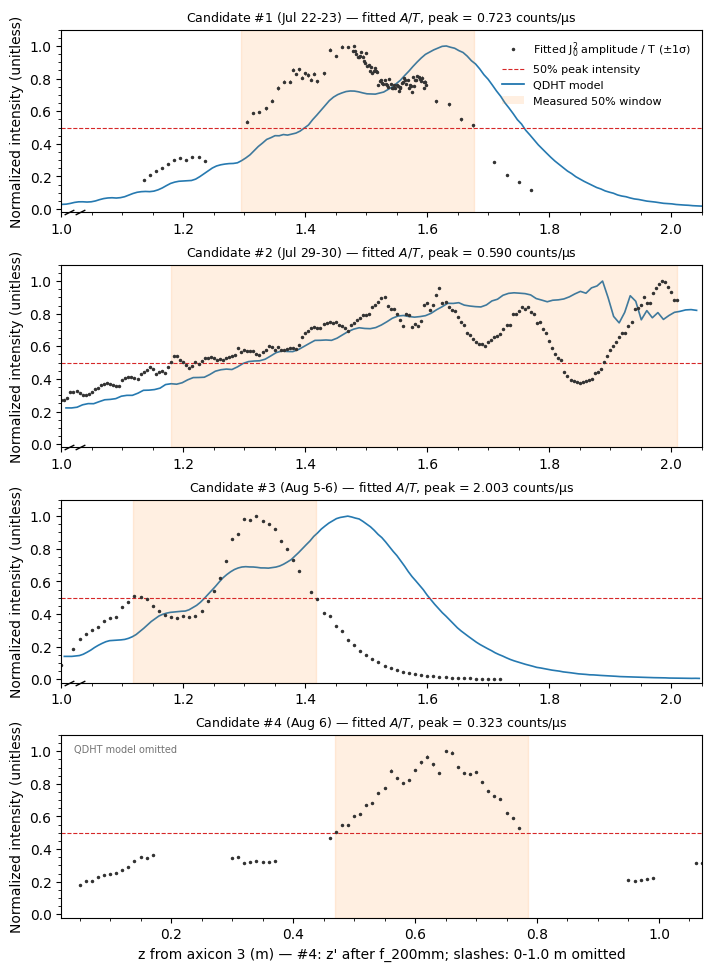

In [9]:
# --- fits envelopes, common x scale: every panel spans exactly 1.05 m --------
# Same normalized envelopes as above, but all four panels get an IDENTICAL
# x-span so the shaded Bessel windows are visually comparable (equal meters
# per inch): #1-#3 show z in [1.00, 2.05] with break slashes at the left
# edge marking the omitted 0-1.0 m run-up (per #1: pre-1.0 m points are
# excluded — no core there, envelope ~0); #4 shows its full image-side
# z' in [0, 1.05] (same span, nothing omitted, no break).
X_SPAN = 1.05
PANEL_XLIM = {1: (1.00, 2.05), 2: (1.00, 2.05), 3: (1.00, 2.05),
              4: (0.02, 1.07)}

# QDHT model on-axis envelopes I(0,z) per candidate, via the webapp's
# simulate_recorded_optic — the SAME model entry point the other notebooks
# use — driven by each dataset's RECORDED OpticConfiguration
# (auto_scan_setup.json: #1 jul22 D=4.59, #2 jul29 D=9.5, #3 aug6 D=4.65;
# waist_is_radius=False reads GaussianBeamWaist_mm as the 1/e^2 diameter,
# the convention validated in exposure_vs_z_analysis_2026_07_13).
# #4 omitted: image-side axis, telescope position unrecorded so no honest
# object->image z mapping. Cached npz; delete
# reductions/qdht_onax_models_recorded.npz to force recompute.
from simulator.qdht_axicon import simulate_recorded_optic

QDHT_RUNS = {1: "auto_scan-2026-07-22_19-26-20",
             2: "auto_scan-2026-07-29_15-56-42",
             3: "auto_scan-2026-08-06_08-38-37"}
QDHT_NPZ = RED / "qdht_onax_models_recorded.npz"

if QDHT_NPZ.exists():
    _q = np.load(QDHT_NPZ)
    QDHT_ONAX = {k: (_q[f"z_{k}"], _q[f"I_{k}"]) for k in QDHT_RUNS}
    print("loaded cached QDHT on-axis models (recorded optics)")
else:
    import json as _json
    QDHT_ONAX = {}
    for key, run in QDHT_RUNS.items():
        optic = _json.loads(
            (REPO / "profiler/data" / run / "auto_scan_setup.json")
            .read_text())["Metadata"]["OpticConfiguration"]
        _pair, _model = simulate_recorded_optic(optic, N=4096, Nz2=40,
                                                Nz3=400, verbose=False)
        QDHT_ONAX[key] = (_model["z3"], _model["onax"])
        print(f"QDHT model computed for {key} from {run} "
              f"(D={optic['GaussianBeamWaist_mm']:g} mm, "
              f"L12={optic['L12_mm']:g}, L23={optic['L23_mm']:g})")
    np.savez_compressed(QDHT_NPZ,
                        **{f"z_{k}": v[0] for k, v in QDHT_ONAX.items()},
                        **{f"I_{k}": v[1] for k, v in QDHT_ONAX.items()})
    print(f"saved {QDHT_NPZ}")


def _slashes(ax):
    # break marker on the bottom spine's left end: omitted axis region
    kw = dict(marker=[(-1, -0.5), (1, 0.5)], markersize=7, linestyle="none",
              color="k", mec="k", mew=1, clip_on=False)
    ax.plot([0.012, 0.030], [0, 0], transform=ax.transAxes, **kw)


fig, axes = plt.subplots(len(FIT_ENV), 1, figsize=(7, 2.4 * len(FIT_ENV)),
                         sharey=True, layout="constrained")
for ax, (label, (ys, I, E, w)) in zip(np.atleast_1d(axes), FIT_ENV.items()):
    cid = CANDIDATE_ID[label]
    x0, x1 = PANEL_XLIM[cid]
    pk = w["peak"]
    m = (ys / 100 >= x0) & (ys / 100 <= x1)
    if cid in QDHT_ONAX:
        zm, Im = QDHT_ONAX[cid]
        mm_ = (zm >= x0) & (zm <= x1)
        ax.plot(zm[mm_], Im[mm_] / Im.max(), "-", color="#0e6ba8", lw=1.2,
                alpha=0.9, zorder=1)
    else:
        ax.text(0.02, 0.95, "QDHT model omitted", transform=ax.transAxes,
                fontsize=7, color="0.45", va="top")
    ax.errorbar(ys[m] / 100, I[m] / pk, yerr=E[m] / pk, fmt=".", ms=3,
                lw=0.8, color="0.2", elinewidth=0.6)
    ax.axhline(0.5, color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None or w["hi"] is not None:
        ax.axvspan(max((w["lo"] or ys[0]) / 100, x0),
                   min((w["hi"] or ys[-1]) / 100, x1),
                   color="tab:orange", alpha=0.12)
    ax.set_xlim(x0, x1)
    ax.set_ylim(-0.02, 1.10)
    ax.set_title(label + f" — fitted $A/T$, peak = {pk:.3f} counts/µs", fontsize=9)
    ax.set_ylabel("Normalized intensity (unitless)")
    ax.minorticks_on()
    # ax.grid(True, which="major", color="0.9", lw=0.5)
    # ax.grid(True, which="minor", color="0.95", lw=0.5)
    if cid != 4:             # #4 omits nothing (full image-side span)
        _slashes(ax)
# legend on the first panel (its upper-right region is empty)
from matplotlib.patches import Patch
np.atleast_1d(axes)[0].legend(handles=[
    plt.Line2D([], [], marker=".", ls="", ms=3, lw=0.8, color="0.2",
               label="Fitted J$_0^2$ amplitude / T (±1σ)"),
    plt.Line2D([], [], ls="--", lw=0.8, color="tab:red",
               label="50% peak intensity"),
    plt.Line2D([], [], ls="-", lw=1.2, color="#0e6ba8",
               label="QDHT model"),
    Patch(facecolor="tab:orange", alpha=0.12, edgecolor="none",
          label="Measured 50% window"),
], loc="upper right", fontsize=8, frameon=False)
np.atleast_1d(axes)[-1].set_xlabel(
    "z from axicon 3 (m) — #4: z' after f_200mm; "
    "slashes: 0-1.0 m omitted")
save_fig("measured_window_envelopes_fits_zoom")
plt.show()

Candidate #1 (Jul 22-23): 106 ladder points (8 dropped at k bounds)


Candidate #2 (Jul 29-30): 203 ladder points


Candidate #3 (Aug 5-6): 71 ladder points


Candidate #4 (Aug 6): 59 ladder points (1 dropped at k bounds)


saved images/final_report_calcs_2026_08_10/core_fit_k_xyz_all_candidates.png


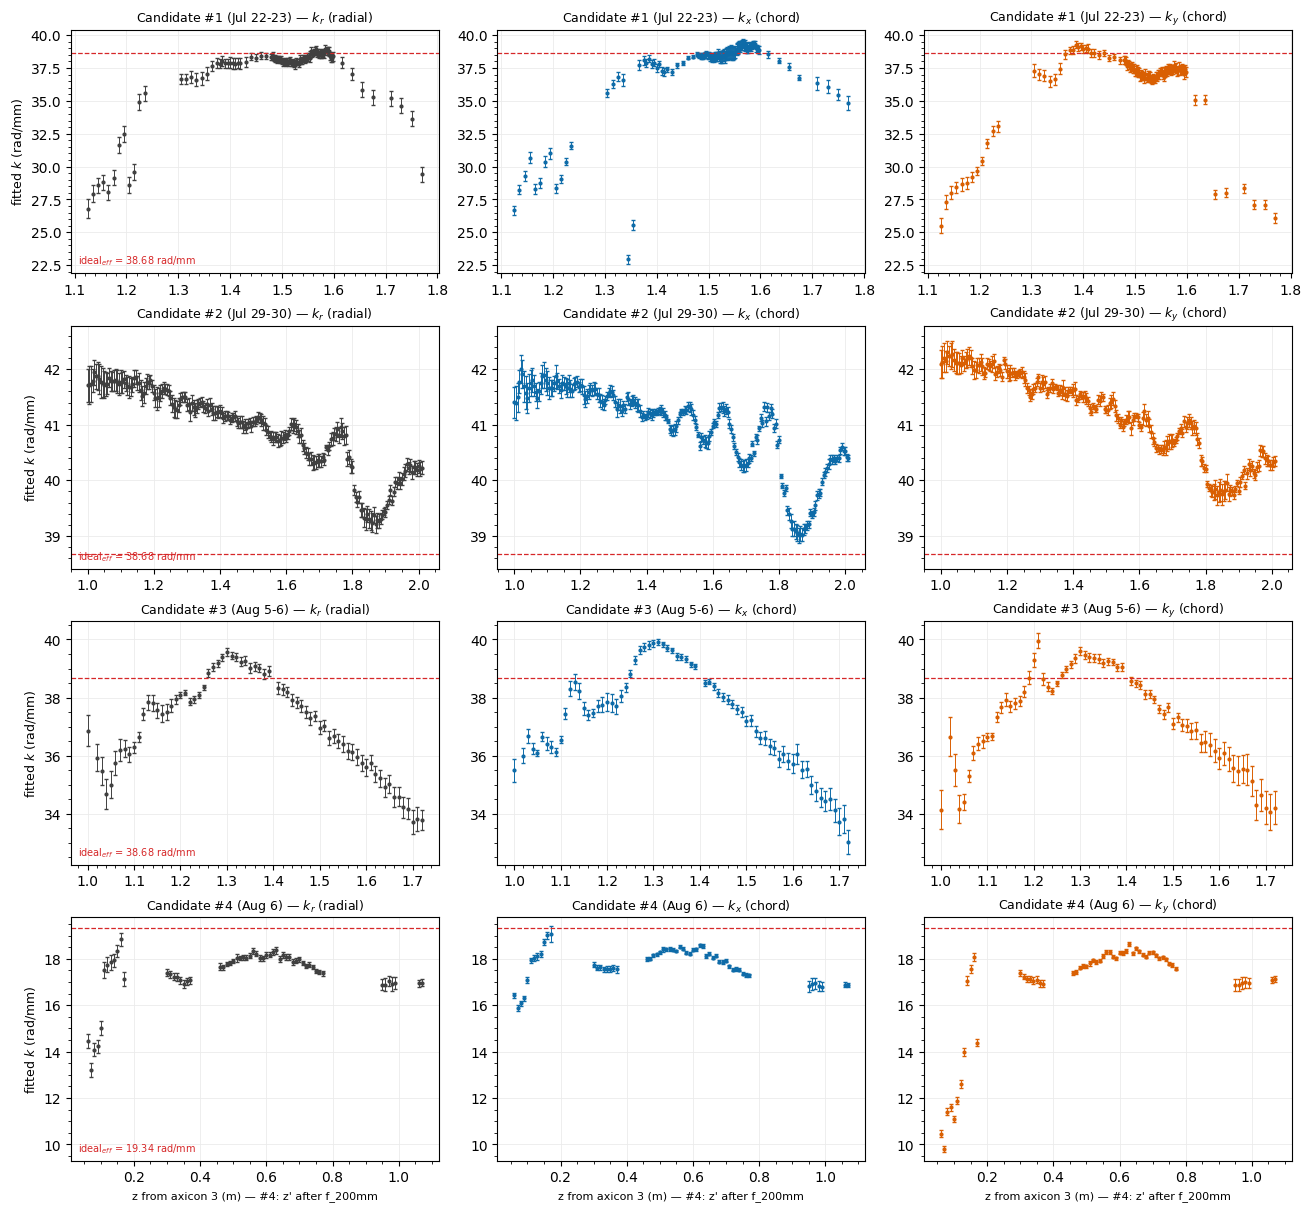

In [10]:
# --- k_r / k_x / k_y ladders with 1-sigma errors, all four candidates --------
# Per-candidate version of the jul30 core_fit_kr_xyz figure, replicating the
# jul30 notebook's fit machinery VERBATIM so the #2 error bars match
# core_fit_kr_vs_y.png exactly:
#   * radial profile: azimuthal mean in 1-PIXEL bins about the sub-pixel
#     centroid of the 5x5 block at the core argmax, r = (i+0.5)*um_per_px
#   * chords: row/column through the core argmax pixel
#   * fits A*J0^2(k(u-u0))+C over |u| <= fit_half; k bounds 0.5-1.5x
#     ideal_eff; u0 pinned (+-1e-9) for the radial fit, free +-35 um for
#     the chords; 1-sigma = sqrt(diag(pcov))
#   * per y: pick the brightest frame by FITTED RADIAL A — no rms cut
# Rows = candidates, columns = k_r / k_x / k_y (report axes: y = image
# vertical = dataset z). Absolute rad/mm; ideal_eff = k_r3 (k_r3/M for the
# #4 telescope). One point per available scan y (brightest frame at each),
# window-restricted — the pre-window fringe frames would pin at the 1.5x
# bound. Fits landing within 1% of a k bound are dropped and counted
# (a pinned k invalidates its sigma).
KXYZ_COLORS = {"kr": "0.25", "kx": "#0e6ba8", "ky": "#d95f02"}


def kfit30(u_um, I, k_eff, fit_half, free_center):
    # jul30 fit_profile: p0 at ideal, k bounds 0.5-1.5x, u0 +-35 um or pinned
    ok = np.isfinite(I) & (np.abs(u_um) <= fit_half)
    u0m = 35.0 if free_center else 1e-9
    popt, pcov = curve_fit(
        lambda u, A, k, u0, C: A * j0(k * (u - u0) * 1e-6) ** 2 + C,
        u_um[ok], I[ok], p0=[np.nanmax(I[ok]), k_eff, 0.0, 0.0],
        bounds=([0, 0.5 * k_eff, -u0m, -np.inf],
                [np.inf, 1.5 * k_eff, u0m, np.inf]))
    perr = np.sqrt(np.diag(pcov))
    resid = I[ok] - (popt[0] * j0(popt[1] * (u_um[ok] - popt[2]) * 1e-6) ** 2
                     + popt[3])
    return popt, perr, np.sqrt(np.mean(resid ** 2)) / popt[0]


def radial_profile30(t, um_px):
    # jul30 radial profile: 5x5-block sub-pixel centroid about the argmax,
    # azimuthal mean in 1-px bins, bin centers at (i+0.5)*um_px
    py, px_ = np.unravel_index(np.nanargmax(t), t.shape)
    w = np.nan_to_num(t[max(py - 2, 0):py + 3, max(px_ - 2, 0):px_ + 3])
    wy, wx = np.mgrid[max(py - 2, 0):py + 3, max(px_ - 2, 0):px_ + 3]
    cy, cx = (w * wy).sum() / w.sum(), (w * wx).sum() / w.sum()
    yy, xx = np.mgrid[0:t.shape[0], 0:t.shape[1]]
    r_um = np.hypot(yy - cy, xx - cx) * um_px
    fin = np.isfinite(t)
    b = (r_um[fin] / um_px).astype(int)
    prof = np.bincount(b, weights=t[fin]) / np.maximum(np.bincount(b), 1)
    r_cent = (np.arange(len(prof)) + 0.5) * um_px
    return r_cent, prof, py, px_


KXYZ = {}
for ds in FITSETS:
    name, pref = ds["label"], ds["frame_prefix"]
    fit_half, excl = ds["fit_half_um"], ds["excluded_runs"]
    z = np.load(RED / ds["thumbs_npz"], allow_pickle=True)
    um_px = (float(z["um_per_px"]) if "um_per_px" in z.files
             else ds["um_per_px"])
    T_exp = exposures(RED / ds["frames_csv"])
    k_eff = KR3 / ds["mag"]
    frames = {}
    for t, y, run, fr in zip(z["thumbs"], z["ys_cm"], z["runs"], z["frames"]):
        if pref and not str(fr).startswith(pref):
            continue
        if str(run) in excl or T_exp.get((str(run), str(fr))) is None:
            continue
        t32 = np.asarray(t, dtype=np.float32)
        if np.isnan(t32).any():
            continue
        frames.setdefault(round(float(y), 1), []).append(t32)
    # restrict to the window region (same limits as the zoom figure) — the
    # pre-window fringe frames have no core lobe and pin at the 1.5x bound
    x0_cm, x1_cm = (2, 107) if ds["candidate_id"] == 4 else (100, 205)
    targets = sorted(y for y in frames if x0_cm <= y <= x1_cm)
    rows_k, n_pinned = [], 0
    for y0 in targets:
        # jul30 pick: brightest frame by FITTED radial A — no rms cut
        best = None
        for t32 in frames[y0]:
            u_r, prof, iy, ix = radial_profile30(t32, um_px)
            try:
                pr, er, rms = kfit30(u_r, prof, k_eff, fit_half, False)
            except RuntimeError:
                continue
            if best is None or pr[0] > best[0][0]:
                best = (pr, er, t32, iy, ix)
        if best is None:
            continue
        pr, er, t32, iy, ix = best
        try:
            px_, ex_, _ = kfit30((np.arange(t32.shape[1]) - ix) * um_px,
                                 t32[iy, :], k_eff, fit_half, True)
            pz_, ez_, _ = kfit30((np.arange(t32.shape[0]) - iy) * um_px,
                                 t32[:, ix], k_eff, fit_half, True)
        except RuntimeError:
            continue
        row = dict(y=y0)
        pinned = False
        for tag, popt, perr in (("kr", pr, er), ("kx", px_, ex_),
                                ("ky", pz_, ez_)):
            if not (0.505 * k_eff < popt[1] < 1.485 * k_eff):
                pinned = True
            row[tag] = popt[1] / k_eff
            row[tag + "_err"] = perr[1] / k_eff
        if pinned:
            n_pinned += 1
            continue
        rows_k.append(row)
    KXYZ[name] = (k_eff, rows_k)
    print(f"{name}: {len(rows_k)} ladder points"
          + (f" ({n_pinned} dropped at k bounds)" if n_pinned else ""))

fig, axes = plt.subplots(len(KXYZ), 3, figsize=(13, 3.0 * len(KXYZ)),
                         sharex="row", layout="constrained")
for (name, (k_eff, rows_k)), axrow in zip(KXYZ.items(), axes):
    ys_k = [r["y"] / 100 for r in rows_k]
    ideal_mm = k_eff / 1e3                      # rad/mm
    # per-row y limits: hug the row's data, keep the ideal line in view
    vals = [r[t] * ideal_mm for r in rows_k for t in ("kr", "kx", "ky")]
    errs = [r[t + "_err"] * ideal_mm for r in rows_k
            for t in ("kr", "kx", "ky")]
    lo = min(min(v - e for v, e in zip(vals, errs)), ideal_mm) - 0.15 * ideal_mm / 38.7
    hi = max(max(v + e for v, e in zip(vals, errs)), ideal_mm) + 0.15 * ideal_mm / 38.7
    pad = 0.03 * (hi - lo)
    for ax, tag, lab in zip(axrow, ("kr", "kx", "ky"),
                            ("$k_r$ (radial)", "$k_x$ (chord)",
                             "$k_y$ (chord)")):
        ax.errorbar(ys_k, [r[tag] * ideal_mm for r in rows_k],
                    yerr=[r[tag + "_err"] * ideal_mm for r in rows_k],
                    fmt=".", ms=4, color=KXYZ_COLORS[tag], elinewidth=0.7,
                    capsize=1.5)
        ax.axhline(ideal_mm, color="tab:red", ls="--", lw=0.9)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f"{name.split(' — ')[0]} — {lab}", fontsize=9)
        ax.minorticks_on()
        ax.grid(True, which="major", color="0.92", lw=0.6)
    axrow[0].set_ylabel("fitted $k$ (rad/mm)", fontsize=9)
    axrow[0].annotate(f"ideal$_{{eff}}$ = {ideal_mm:.2f} rad/mm",
                      xy=(0.02, 0.04), xycoords="axes fraction", fontsize=7,
                      color="tab:red")
for ax in axes[-1]:
    ax.set_xlabel("z from axicon 3 (m) — #4: z' after f_200mm", fontsize=8)
save_fig("core_fit_k_xyz_all_candidates")
plt.show()

saved images/final_report_calcs_2026_08_10/measured_windows_with_kr_ladder.png


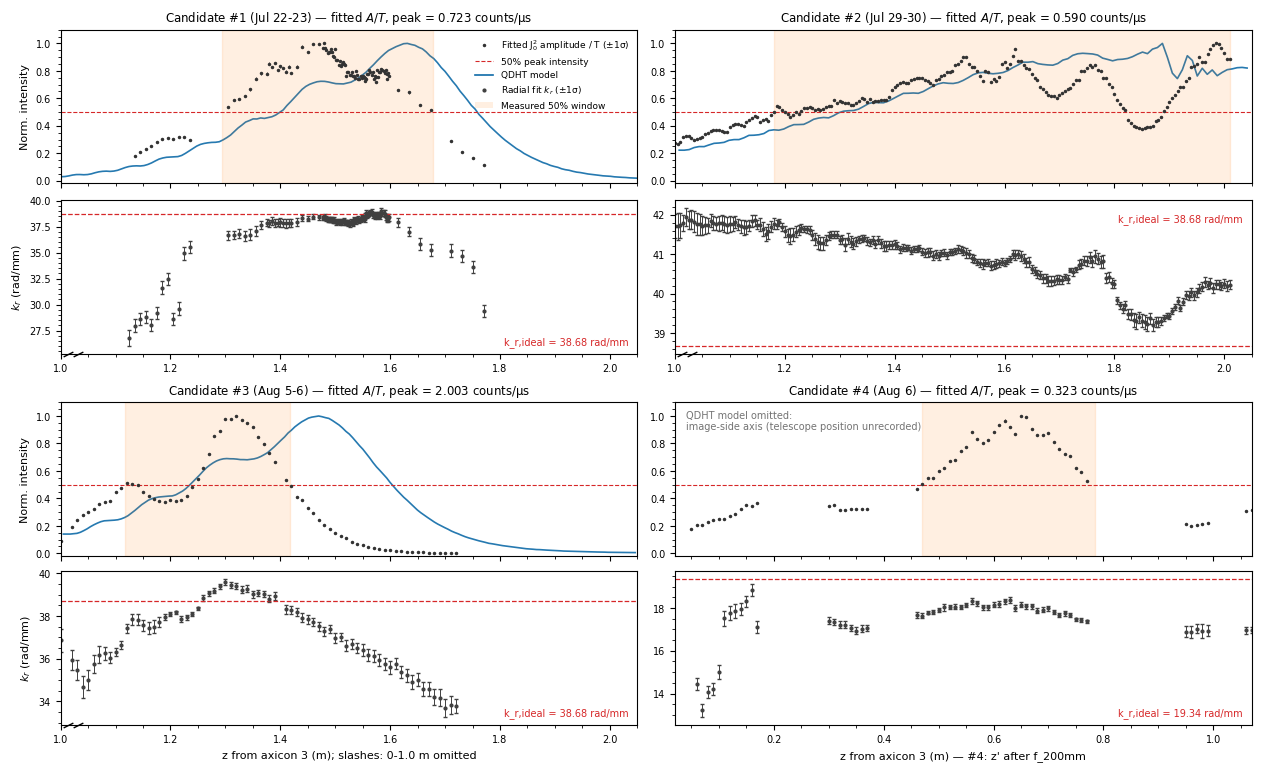

In [11]:
# --- combined report figure: zoom envelopes + k_r ladder underneath ----------
# Two-column layout: candidates #1/#2 in the top pair-row, #3/#4 in the
# bottom. Each candidate is a PAIR of panels on a shared z axis: the
# common-x-scale envelope zoom (identical to measured_window_envelopes_fits
# _zoom) on top, the radial-fit k_r ladder (identical machinery/data to the
# k_r column of core_fit_k_xyz_all_candidates) underneath. Uses FIT_ENV,
# QDHT_ONAX, PANEL_XLIM, _slashes from the zoom cell and KXYZ from the
# ladder cell — run those first.
from matplotlib.patches import Patch

fig, axes = plt.subplots(4, 2, figsize=(12.5, 7.6),
                         height_ratios=[1, 1, 1, 1], width_ratios=[1, 1],
                         layout="constrained")
for j, (label, (ys, I, E, w)) in enumerate(FIT_ENV.items()):
    ax_e, ax_k = axes[2 * (j // 2), j % 2], axes[2 * (j // 2) + 1, j % 2]
    cid = CANDIDATE_ID[label]
    x0, x1 = PANEL_XLIM[cid]
    pk = w["peak"]
    m = (ys / 100 >= x0) & (ys / 100 <= x1)

    # -- top: envelope zoom panel (same as the zoom figure) --
    if cid in QDHT_ONAX:
        zm, Im = QDHT_ONAX[cid]
        mm_ = (zm >= x0) & (zm <= x1)
        ax_e.plot(zm[mm_], Im[mm_] / Im.max(), "-", color="#0e6ba8", lw=1.2,
                  alpha=0.9, zorder=1)
    else:
        ax_e.text(0.02, 0.95, "QDHT model omitted:\nimage-side axis "
                  "(telescope position unrecorded)",
                  transform=ax_e.transAxes, fontsize=7, color="0.45",
                  va="top")
    ax_e.errorbar(ys[m] / 100, I[m] / pk, yerr=E[m] / pk, fmt=".", ms=3,
                  lw=0.8, color="0.2", elinewidth=0.6)
    ax_e.axhline(0.5, color="tab:red", lw=0.8, ls="--")
    win = (max((w["lo"] or ys[0]) / 100, x0),
           min((w["hi"] or ys[-1]) / 100, x1))
    if w["lo"] is not None or w["hi"] is not None:
        ax_e.axvspan(*win, color="tab:orange", alpha=0.12)
    ax_e.set_ylim(-0.02, 1.10)
    ax_e.set_title(label + f" — fitted $A/T$, peak = {pk:.3f} counts/µs",
                   fontsize=8.5)
    ax_e.tick_params(labelbottom=False)

    # -- bottom: radial-fit k_r ladder (same data as the k_xyz figure) --
    k_eff, rows_k = KXYZ[label]
    ideal_mm = k_eff / 1e3
    
    ys_k = [r["y"] / 100 for r in rows_k]
    kr_v = [r["kr"] * ideal_mm for r in rows_k]
    kr_e = [r["kr_err"] * ideal_mm for r in rows_k]

    ax_k.errorbar(ys_k, kr_v, yerr=kr_e, fmt=".", ms=4,
                  color=KXYZ_COLORS["kr"], elinewidth=0.7, capsize=1.5)
    ax_k.axhline(ideal_mm, color="tab:red", ls="--", lw=0.9)
    # if w["lo"] is not None or w["hi"] is not None:
    #     ax_k.axvspan(*win, color="tab:orange", alpha=0.12)
    lo_y = min(min(v - e for v, e in zip(kr_v, kr_e)), ideal_mm)
    hi_y = max(max(v + e for v, e in zip(kr_v, kr_e)), ideal_mm)
    pad = 0.06 * (hi_y - lo_y)
    ax_k.set_ylim(lo_y - pad, hi_y + pad)
    # annotation dodges the ideal line: bottom-right unless the line is there
    ann_y = 0.86 if (ideal_mm - (lo_y - pad)) < 0.25 * (hi_y - lo_y + 2 * pad) else 0.06
    ax_k.annotate(f"k_r,ideal = {ideal_mm:.2f} rad/mm",
                  xy=(0.985, ann_y), xycoords="axes fraction", fontsize=7,
                  color="tab:red", ha="right")
    if j % 2 == 0:
        ax_e.set_ylabel("Norm. intensity", fontsize=8)
        ax_k.set_ylabel("$k_r$ (rad/mm)", fontsize=8)

    for ax in (ax_e, ax_k):
        ax.set_xlim(x0, x1)
        ax.minorticks_on()
        ax.tick_params(labelsize=7)
    if cid != 4:          # #4 omits nothing (full image-side span)
        _slashes(ax_k)
    if j // 2 == 1:          # bottom pair-row carries the x label
        ax_k.set_xlabel("z from axicon 3 (m)" +
                        (" — #4: z' after f_200mm" if cid == 4 else
                         "; slashes: 0-1.0 m omitted"), fontsize=8)

axes[0, 0].legend(handles=[
    plt.Line2D([], [], marker=".", ls="", ms=3, lw=0.8, color="0.2",
               label="Fitted J$_0^2$ amplitude / T (±1σ)"),
    plt.Line2D([], [], ls="--", lw=0.8, color="tab:red",
               label="50% peak intensity"),
    plt.Line2D([], [], ls="-", lw=1.2, color="#0e6ba8",
               label="QDHT model"),
    plt.Line2D([], [], marker=".", ls="", ms=4, color=KXYZ_COLORS["kr"],
               label="Radial fit $k_r$ (±1σ)"),
    Patch(facecolor="tab:orange", alpha=0.12, edgecolor="none",
          label="Measured 50% window"),
], loc="upper right", fontsize=6.5, frameon=False)
save_fig("measured_windows_with_kr_ladder")
plt.show()

kr 1-sigma color scale: 0.20% - 1.60% (median 0.50%)
saved images/final_report_calcs_2026_08_10/measured_window_envelopes_kr_err_colored_log.png


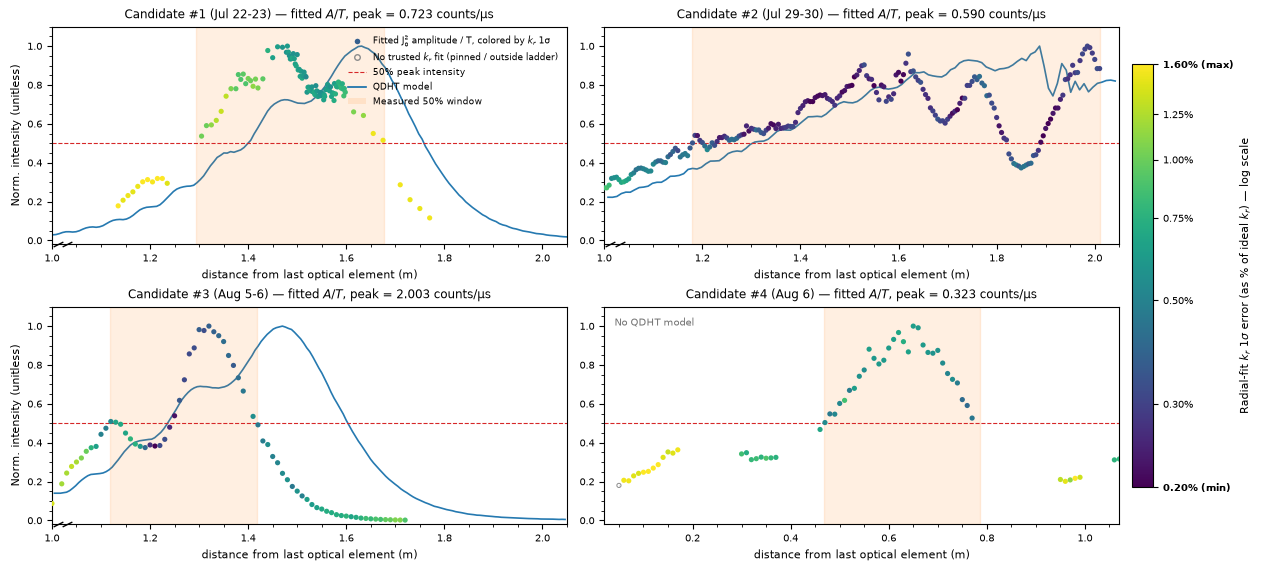

saved images/final_report_calcs_2026_08_10/measured_window_envelopes_kr_err_colored_linear.png


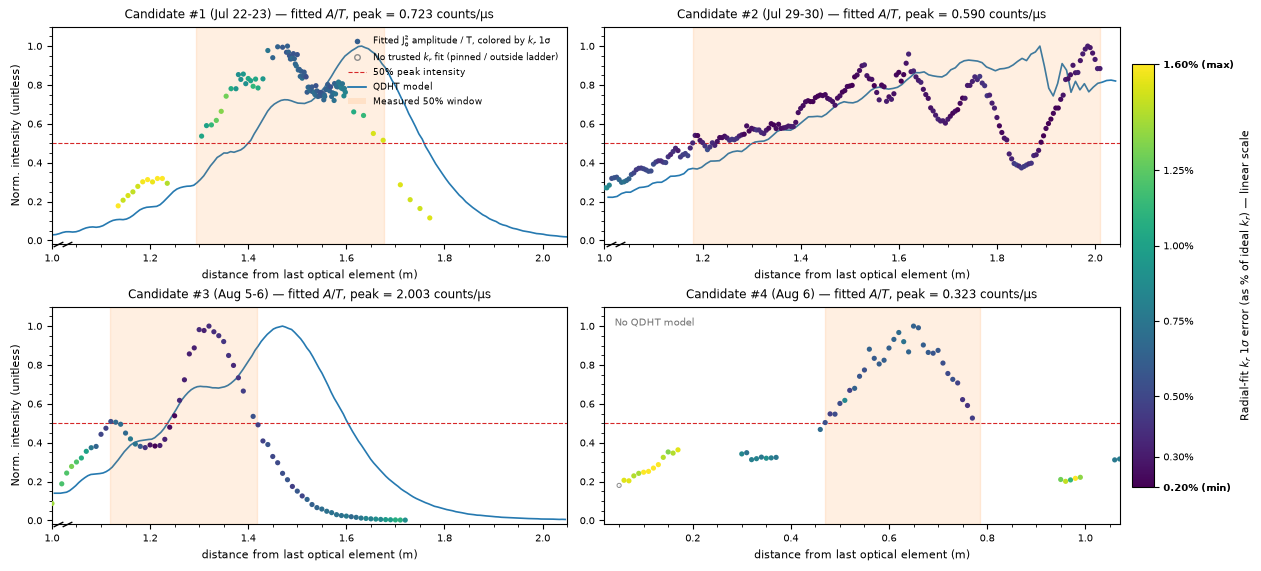

saved images/final_report_calcs_2026_08_10/measured_window_envelopes_kr_err_colored_pow05.png


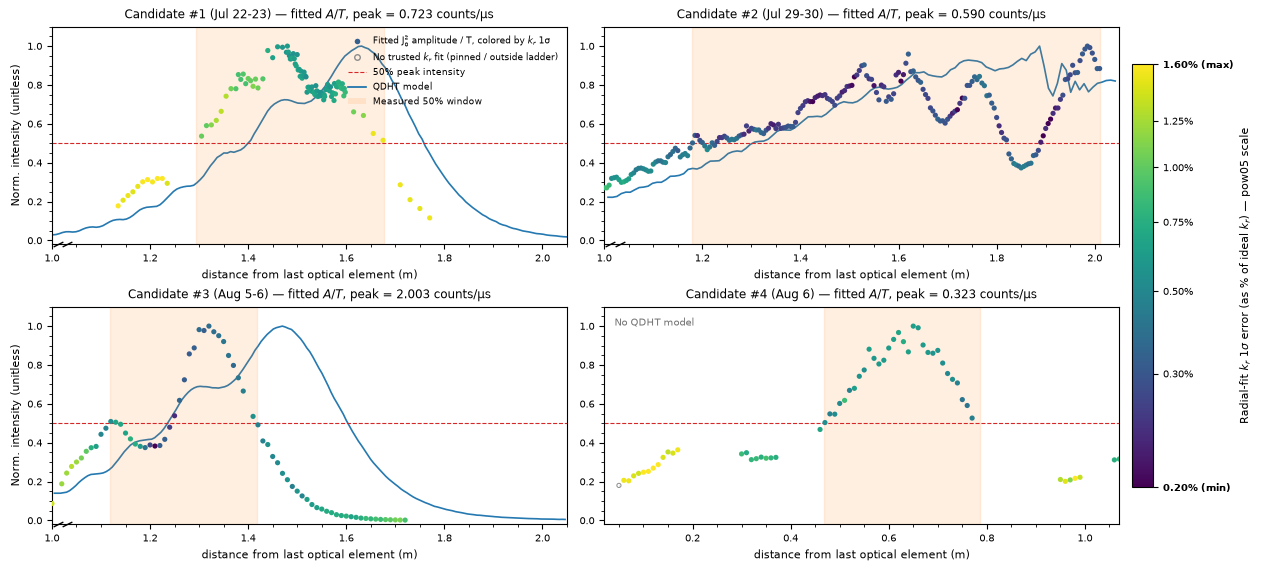

In [ ]:
# --- variant: zoom envelopes with points COLORED by k_r 1-sigma error --------
# Single-panel encoding: the envelope points (normalized fitted A/T vs z)
# carry the k_r fit quality as COLOR — each point is colored by the relative
# 1-sigma error of that y's radial k_r fit (sigma_kr / k_eff, %, from the
# jul30-machinery ladder / KXYZ). Rendered THREE times for comparison —
# log, linear, and PowerNorm(0.5) color scales — with the scale ends
# labeled explicitly on every colorbar. Points with NO trustworthy k_r at
# that y (fit pinned at the 0.5-1.5x bounds, no fit, or outside the ladder
# window) are open grey circles — shown, but explicitly unquantified.
# Needs FIT_ENV/QDHT_ONAX/PANEL_XLIM/_slashes (zoom cell) + KXYZ (ladder
# cell) — run those first.
from matplotlib.colors import LogNorm, Normalize, PowerNorm
from matplotlib.patches import Patch
import matplotlib.cm as mcm

CERR = {lab: {r["y"]: r["kr_err"] * 100 for r in rows}
        for lab, (k_eff, rows) in KXYZ.items()}
_all = np.array([v for d in CERR.values() for v in d.values()])

VMIN, VMAX = np.percentile(_all, 2), np.percentile(_all, 98)
CMAP_ERR = plt.get_cmap("viridis")
NORMS = (("log", LogNorm(vmin=VMIN, vmax=VMAX)),
         ("linear", Normalize(vmin=VMIN, vmax=VMAX)),
         ("pow05", PowerNorm(0.5, vmin=VMIN, vmax=VMAX)))
print(f"kr 1-sigma color scale: {VMIN:.2f}% - {VMAX:.2f}% "
      f"(median {np.median(_all):.2f}%)")

for norm_tag, NORM_ERR in NORMS:
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 5.6), layout="constrained")
    for j, (label, (ys, I, E, w)) in enumerate(FIT_ENV.items()):
        ax = axes[j // 2, j % 2]
        cid = CANDIDATE_ID[label]
        x0, x1 = PANEL_XLIM[cid]
        pk = w["peak"]
        m = (ys / 100 >= x0) & (ys / 100 <= x1)
        if cid in QDHT_ONAX:
            zm, Im = QDHT_ONAX[cid]
            mm_ = (zm >= x0) & (zm <= x1)
            ax.plot(zm[mm_], Im[mm_] / Im.max(), "-", color="#0e6ba8",
                    lw=1.2, alpha=0.9, zorder=1)
        else:
            ax.text(0.02, 0.95, "No QDHT model", transform=ax.transAxes,
                    fontsize=7, color="0.45", va="top")
        # intensity error bars, neutral grey under the colored points
        ax.errorbar(ys[m] / 100, I[m] / pk, yerr=E[m] / pk, fmt="none",
                    ecolor="0.8", elinewidth=0.6, zorder=2)
        # split: y positions with a trusted k_r sigma vs without
        errmap = CERR[label]
        cvals = np.array([errmap.get(round(float(y), 1), np.nan) for y in ys])
        has = m & np.isfinite(cvals)
        ax.scatter(ys[~has & m] / 100, I[~has & m] / pk, s=9,
                   facecolors="none", edgecolors="0.55", linewidths=0.7,
                   zorder=3)
        ax.scatter(ys[has] / 100, I[has] / pk, c=cvals[has], cmap=CMAP_ERR,
                   norm=NORM_ERR, s=14, edgecolors="none", zorder=4)
        ax.axhline(0.5, color="tab:red", lw=0.8, ls="--")
        if w["lo"] is not None or w["hi"] is not None:
            ax.axvspan(max((w["lo"] or ys[0]) / 100, x0),
                       min((w["hi"] or ys[-1]) / 100, x1),
                       color="tab:orange", alpha=0.12)
        ax.set_xlim(x0, x1)
        ax.set_ylim(-0.02, 1.10)
        ax.set_title(label + f" — fitted $A/T$, peak = {pk:.3f} counts/µs",
                     fontsize=8.5)
        ax.minorticks_on()
        ax.tick_params(labelsize=7)
        if j % 2 == 0:
            ax.set_ylabel("Norm. intensity (unitless)", fontsize=8)
        if cid != 4:
            _slashes(ax)
        ax.set_xlabel("distance from last optical element (m)", fontsize=8)

    cb = fig.colorbar(mcm.ScalarMappable(norm=NORM_ERR, cmap=CMAP_ERR),
                      ax=axes, shrink=0.85, pad=0.012)
    # explicit ticks: exact scale ends (bold) + round interior values
    interior = [t for t in (0.3, 0.5, 0.75, 1.0, 1.25)
                if VMIN * 1.05 < t < VMAX * 0.95]
    cb.set_ticks([VMIN] + interior + [VMAX])
    cb.set_ticklabels([f"{VMIN:.2f}% (min)"]
                      + [f"{t:.2f}%" for t in interior]
                      + [f"{VMAX:.2f}% (max)"])
    cb.ax.minorticks_off()
    for _tl in (cb.ax.get_yticklabels()[0], cb.ax.get_yticklabels()[-1]):
        _tl.set_fontweight("bold")
    cb.set_label(r"Radial-fit $k_r$ $1 \sigma$ error (as % of ideal $k_r$)"
                 f" — {norm_tag} scale", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    axes[0, 0].legend(handles=[
        plt.Line2D([], [], marker="o", ls="", ms=4, mfc=CMAP_ERR(0.3),
                   mec="none",
                   label="Fitted J$_0^2$ amplitude / T, colored by $k_r$ 1σ"),
        plt.Line2D([], [], marker="o", ls="", ms=4, mfc="none", mec="0.55",
                   label="No trusted $k_r$ fit (pinned / outside ladder)"),
        plt.Line2D([], [], ls="--", lw=0.8, color="tab:red",
                   label="50% peak intensity"),
        plt.Line2D([], [], ls="-", lw=1.2, color="#0e6ba8",
                   label="QDHT model"),
        Patch(facecolor="tab:orange", alpha=0.12, edgecolor="none",
              label="Measured 50% window"),
    ], loc="upper right", fontsize=6.5, frameon=False)
    save_fig(f"measured_window_envelopes_kr_err_colored_{norm_tag}")
    plt.show()

kr deviation color scale: +-10.0% (symmetric; median +0.4%; 42/439 points saturate beyond the scale ends)
saved images/final_report_calcs_2026_08_10/measured_window_envelopes_kr_value_colored.png


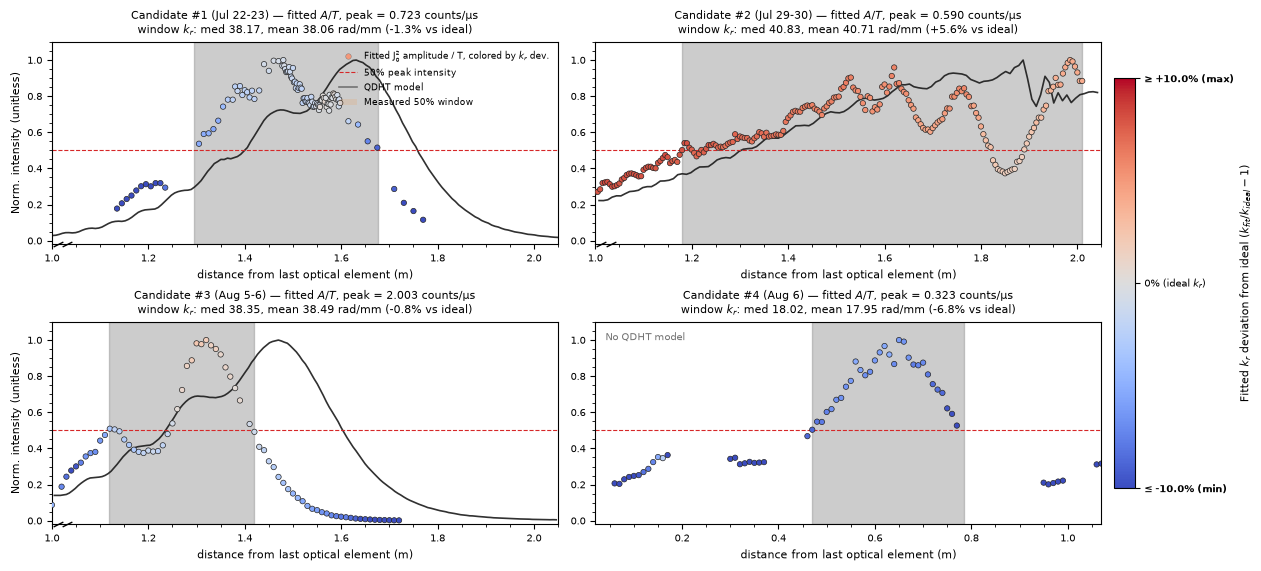

In [524]:
# --- variant: zoom envelopes with points COLORED by the k_r FIT VALUE --------
# Same layout as the error-colored figure, but color now encodes the fitted
# k_r itself, as % deviation from ideal_eff: (k_fit/k_eff - 1) x 100.
# Signed quantity -> DIVERGING colormap (coolwarm) anchored at 0% = ideal
# (white); blue = k below ideal (core LARGER than prescribed), red = k above
# ideal (core SMALLER). SYMMETRIC range +-DLIM: equal color slope on both
# sides of ideal. Per-panel title: median/mean fitted k_r over the measured
# Bessel window. Scale ends + the ideal center are labeled
# explicitly. Open grey circles = no trustworthy k_r at that y (pinned /
# no fit / outside ladder). Needs FIT_ENV/QDHT_ONAX/PANEL_XLIM/_slashes
# (zoom cell) + KXYZ (ladder cell) — run those first.
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import matplotlib.cm as mcm

CDEV = {lab: {r["y"]: (r["kr"] - 1) * 100 for r in rows}
        for lab, (k_eff, rows) in KXYZ.items()}
_alld = np.array([v for d in CDEV.values() for v in d.values()])
# SYMMETRIC scale: equal color slope on both sides of ideal. K_R_SCALE_MAX
# caps the range (fraction, e.g. 0.10 = +-10%): deviations beyond it
# SATURATE at the end colors, trading fringe-point resolution for contrast
# inside the window. Set to None for the data-driven +-max(|2nd|,|98th| pct).
K_R_SCALE_MAX = 0.10
if K_R_SCALE_MAX is not None:
    DLIM = K_R_SCALE_MAX * 100
else:
    DLIM = max(abs(np.percentile(_alld, 2)), abs(np.percentile(_alld, 98)))
NORM_DEV = Normalize(vmin=-DLIM, vmax=DLIM)
CMAP_DEV = plt.get_cmap("coolwarm")
n_clip = int((np.abs(_alld) > DLIM).sum())
print(f"kr deviation color scale: +-{DLIM:.1f}% (symmetric; "
      f"median {np.median(_alld):+.1f}%; {n_clip}/{len(_alld)} points "
      f"saturate beyond the scale ends)")

fig, axes = plt.subplots(2, 2, figsize=(12.5, 5.6), layout="constrained")
for j, (label, (ys, I, E, w)) in enumerate(FIT_ENV.items()):
    ax = axes[j // 2, j % 2]
    cid = CANDIDATE_ID[label]
    x0, x1 = PANEL_XLIM[cid]
    pk = w["peak"]
    m = (ys / 100 >= x0) & (ys / 100 <= x1)
    if cid in QDHT_ONAX:
        zm, Im = QDHT_ONAX[cid]
        mm_ = (zm >= x0) & (zm <= x1)
        ax.plot(zm[mm_], Im[mm_] / Im.max(), "-", color="0.1", lw=1.2,
                alpha=0.9, zorder=1)
    else:
        ax.text(0.02, 0.95, "No QDHT model", transform=ax.transAxes,
                fontsize=7, color="0.45", va="top")
    devmap = CDEV[label]
    cvals = np.array([devmap.get(round(float(y), 1), np.nan) for y in ys])
    has = m & np.isfinite(cvals)
    ax.scatter(ys[has] / 100, I[has] / pk, c=cvals[has], cmap=CMAP_DEV,
               norm=NORM_DEV, s=15, edgecolors="0.15", linewidths=0.5,
               zorder=4, label="Measured data (colored by $k_r$ deviation)")
    ax.axhline(0.5, color="tab:red", lw=0.8, ls="--")
    if w["lo"] is not None or w["hi"] is not None:
        ax.axvspan(max((w["lo"] or ys[0]) / 100, x0),
                   min((w["hi"] or ys[-1]) / 100, x1),
                   color="grey", alpha=0.4, zorder=0)
    ax.set_xlim(x0, x1)
    ax.set_ylim(-0.02, 1.10)
    # median/mean fitted k_r over the measured Bessel window (rad/mm)
    k_eff_l, rows_l = KXYZ[label]
    _wlo = (w["lo"] if w["lo"] is not None else ys[0])
    _whi = (w["hi"] if w["hi"] is not None else ys[-1])
    kw = np.array([r["kr"] for r in rows_l if _wlo <= r["y"] <= _whi])
    if len(kw):
        _im = k_eff_l / 1e3
        stat = (f"window $k_r$: med {np.median(kw) * _im:.2f}, "
                f"mean {np.mean(kw) * _im:.2f} rad/mm "
                f"({(np.median(kw) - 1) * 100:+.1f}% vs ideal)")
    else:
        stat = "window $k_r$: no ladder points in window"
    ax.set_title(label + f" — fitted $A/T$, peak = {pk:.3f} counts/µs\n"
                 + stat, fontsize=8)
    ax.minorticks_on()
    ax.tick_params(labelsize=7)
    if j % 2 == 0:
        ax.set_ylabel("Norm. intensity (unitless)", fontsize=8)
    if cid != 4:
        _slashes(ax)
    ax.set_xlabel("distance from last optical element (m)", fontsize=8)

cb = fig.colorbar(mcm.ScalarMappable(norm=NORM_DEV, cmap=CMAP_DEV),
                  ax=axes, shrink=0.85, pad=0.012)
interior = [t for t in (-20.0, -10.0, 10.0, 20.0)
            if -DLIM * 0.95 < t < DLIM * 0.95]
ticks = [-DLIM] + sorted(interior + [0.0]) + [DLIM]
cb.set_ticks(ticks)
cb.set_ticklabels([f"≤ -{DLIM:.1f}% (min)"]
                  + [("0% (ideal $k_r$)" if t == 0.0 else f"{t:+.0f}%")
                     for t in sorted(interior + [0.0])]
                  + [f"≥ +{DLIM:.1f}% (max)"])
cb.ax.minorticks_off()
for _tl in (cb.ax.get_yticklabels()[0], cb.ax.get_yticklabels()[-1]):
    _tl.set_fontweight("bold")
cb.set_label(r"Fitted $k_r$ deviation from ideal ($k_{fit}/k_{ideal} - 1$)", fontsize=8)
cb.ax.tick_params(labelsize=7)
axes[0, 0].legend(handles=[
    plt.Line2D([], [], marker="o", ls="", ms=4, mfc=CMAP_DEV(0.75),
               mec="0.4", mew=0.25,
               label="Fitted J$_0^2$ amplitude / T, colored by $k_r$ dev."),
    plt.Line2D([], [], ls="--", lw=0.8, color="tab:red",
               label="50% peak intensity"),
    plt.Line2D([], [], ls="-", lw=1.2, color="0.45", label="QDHT model"),
    Patch(facecolor="tab:orange", alpha=0.12, edgecolor="none",
          label="Measured 50% window"),
], loc="upper right", fontsize=6.5, frameon=False)
save_fig("measured_window_envelopes_kr_value_colored")
plt.show()